# MindTune Brainwave EDA — Sentiment from EEG

**Dataset:** `featured_mindtune.csv` — 11,945 samples across 3 sentiment classes (calm / neutral / stressed)  
**Signal:** NeuroSky MindWave — 8 EEG frequency bands + attention + meditation  

---
### Contents
1. Setup & Data Loading  
2. Dataset Overview  
3. Class Distribution  
4. EEG Band Distributions per Class  
5. Attention & Meditation Deep-Dive  
6. Frequency Band Radar Charts  
7. Derived Ratios (Theta/Beta, Alpha/Beta, Slow/Fast)  
8. Rolling Statistics — Temporal Stability  
9. Correlation Heatmap  
10. Time-Series for a Single Session  
11. Event Marker Analysis  
12. Signal Quality Analysis  
13. PCA — Low-Dimensional View  
14. t-SNE — Cluster Separation  
15. Per-Participant Variability  

## 1. Setup & Data Loading

In [2]:
# Install / upgrade dependencies if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn plotly -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ── Aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

CLASS_COLORS = {"calm": "#2ecc71", "neutral": "#3498db", "stressed": "#e74c3c"}
CLASS_ORDER  = ["calm", "neutral", "stressed"]
PALETTE      = [CLASS_COLORS[c] for c in CLASS_ORDER]

BAND_COLS = ["delta_pct", "theta_pct", "low_alpha_pct", "high_alpha_pct",
             "low_beta_pct", "high_beta_pct", "low_gamma_pct", "mid_gamma_pct"]

BAND_LABELS = ["Delta", "Theta", "Low-α", "High-α",
               "Low-β", "High-β", "Low-γ", "Mid-γ"]

RATIO_COLS  = ["theta_beta_ratio", "alpha_beta_ratio", "slow_fast_ratio"]
RATIO_LABELS = ["Theta/Beta", "Alpha/Beta", "Slow/Fast"]

EVENT_COLS  = ["marker_ev_praised_active", "marker_ev_qna_active",
               "marker_ev_question_active", "marker_ev_scolded_active",
               "marker_ev_speaking_active", "marker_ev_tech_issue_active"]
EVENT_LABELS = ["Praised", "Q&A", "Question", "Scolded", "Speaking", "Tech-issue"]

print("Libraries loaded.")

Libraries loaded.


In [3]:
df = pd.read_csv("featured_mindtune.csv")
df["label_3class"] = pd.Categorical(df["label_3class"], categories=CLASS_ORDER, ordered=True)
df["timestamp"]    = pd.to_datetime(df["timestamp_ms"], unit="ms")

print(f"Shape : {df.shape}")
print(f"Labels: {df['label_3class'].value_counts().to_dict()}")
df.head(3)

Shape : (11945, 43)
Labels: {'stressed': 6186, 'neutral': 3662, 'calm': 2097}


,session_id,participant_id,timestamp_ms,label_3class,delta_pct,theta_pct,low_alpha_pct,high_alpha_pct,low_beta_pct,high_beta_pct,...,low_beta_pct_roll_mean_5,low_beta_pct_roll_std_5,high_beta_pct_roll_mean_5,high_beta_pct_roll_std_5,attention_roll_mean_5,attention_roll_std_5,meditation_roll_mean_5,meditation_roll_std_5,label_encoded,timestamp
0,0054,P0054,1774857972940,neutral,0.932067,0.017215,0.004965,0.017741,0.017175,0.007442,...,0.017175,0.000000,0.007442,0.000000,77.0,0.0,97.0,0.0,1,2026-03-30 08:06:12.940
1,0054,P0054,1774857973920,neutral,0.330172,0.166994,0.084490,0.121249,0.132139,0.105784,...,0.074657,0.081292,0.056613,0.069538,77.0,0.0,97.0,0.0,1,2026-03-30 08:06:13.920
2,0054,P0054,1774857976914,neutral,0.603905,0.206416,0.071130,0.051604,0.029289,0.023710,...,0.059534,0.063169,0.045645,0.052713,77.0,0.0,97.0,0.0,1,2026-03-30 08:06:16.914


## 2. Dataset Overview

In [4]:
print("=== Basic Info ===")
print(f"  Rows            : {len(df):,}")
print(f"  Columns         : {df.shape[1]}")
print(f"  Participants    : {df['participant_id'].nunique()}")
print(f"  Sessions        : {df['session_id'].nunique()}")
print(f"  Missing values  : {df.isnull().sum().sum()}")
print()
print("=== Numeric Summary ===")
df[BAND_COLS + ["attention", "meditation"] + RATIO_COLS].describe().round(3)

=== Basic Info ===
  Rows            : 11,945
  Columns         : 43
  Participants    : 54
  Sessions        : 65
  Missing values  : 0

=== Numeric Summary ===


,delta_pct,theta_pct,low_alpha_pct,high_alpha_pct,low_beta_pct,high_beta_pct,low_gamma_pct,mid_gamma_pct,attention,meditation,theta_beta_ratio,alpha_beta_ratio,slow_fast_ratio
count,11945.000,11945.000,11945.000,11945.000,11945.000,11945.000,11945.000,11945.000,11945.000,11945.000,11945.000,11945.000,11945.000
mean,0.582,0.182,0.057,0.052,0.041,0.036,0.022,0.024,31.393,33.029,978.122,589.413,2058.493
std,0.238,0.128,0.056,0.050,0.042,0.038,0.027,0.034,29.220,29.416,27005.822,20448.711,44008.906
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.399,0.084,0.018,0.016,0.013,0.011,0.005,0.005,0.000,0.000,1.368,0.895,3.765
50%,0.604,0.156,0.039,0.036,0.028,0.024,0.012,0.013,34.000,37.000,2.717,1.496,8.861
75%,0.784,0.255,0.078,0.072,0.055,0.049,0.031,0.033,54.000,56.000,5.168,2.465,20.320
max,1.000,1.000,1.000,1.000,0.543,1.000,0.351,1.000,100.000,100.000,1000000.000,1000000.000,1000000.000


## 3. Class Distribution

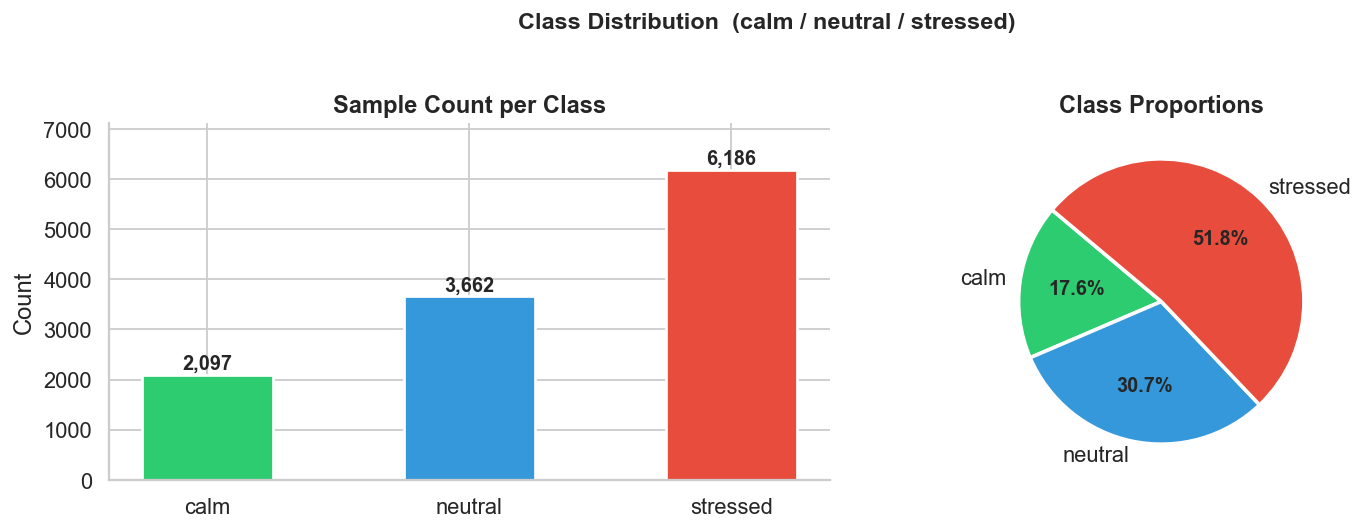

In [5]:
counts = df["label_3class"].value_counts().reindex(CLASS_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax = axes[0]
bars = ax.bar(CLASS_ORDER, counts.values, color=PALETTE, edgecolor="white", linewidth=1.5, width=0.5)
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{cnt:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_title("Sample Count per Class", fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.15)

# Pie chart
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    counts.values, labels=CLASS_ORDER, colors=PALETTE,
    autopct="%1.1f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
ax.set_title("Class Proportions", fontweight="bold")

plt.suptitle("Class Distribution  (calm / neutral / stressed)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. EEG Band Distributions per Class
### 4a. Violin plots — full distribution shape

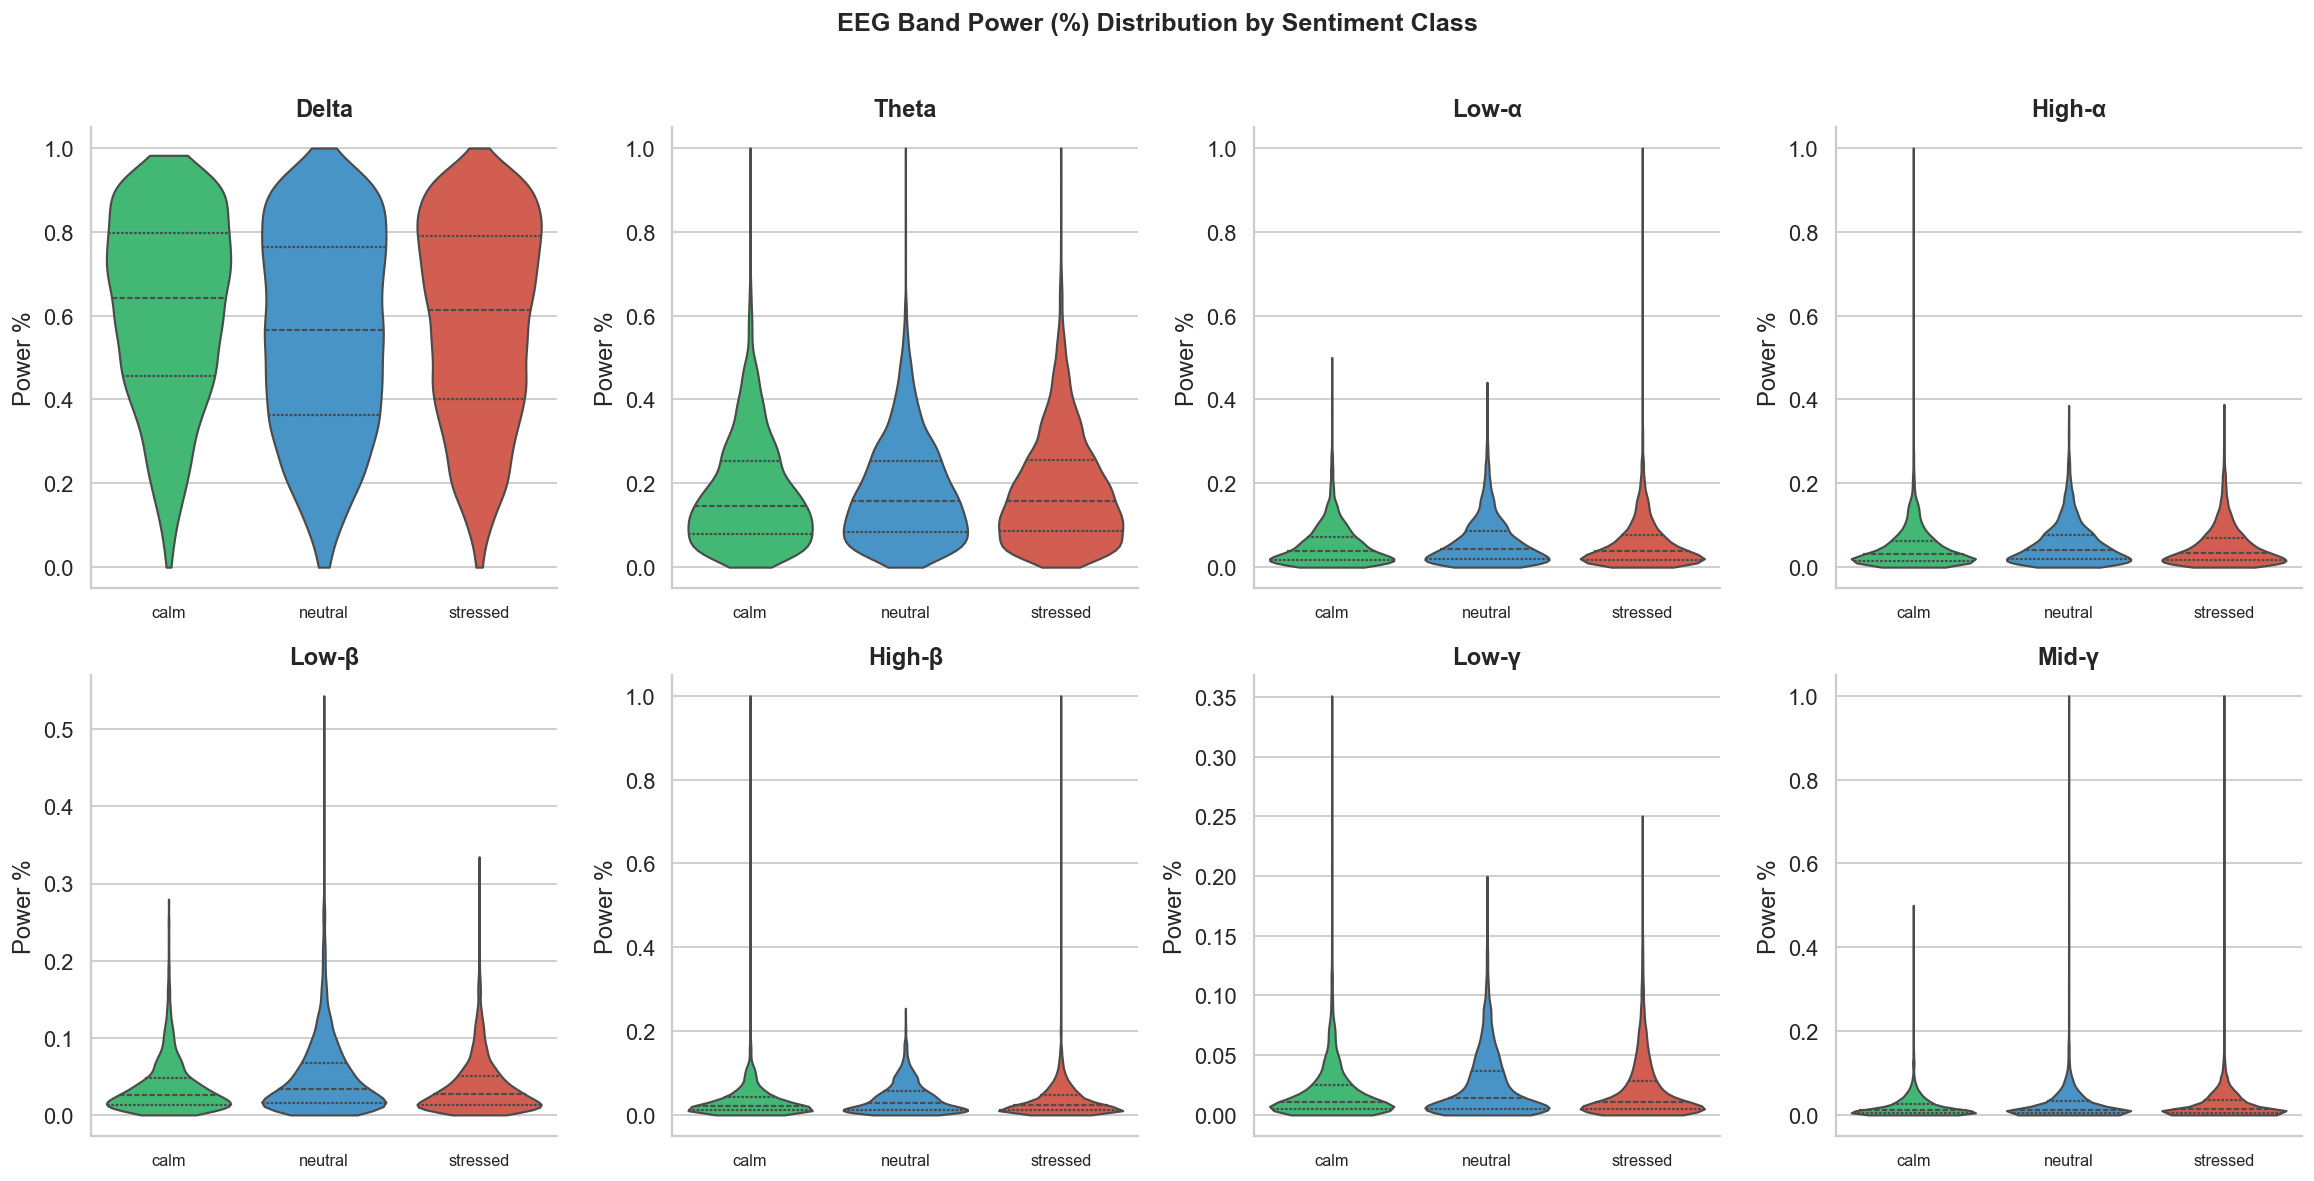

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, col, label in zip(axes, BAND_COLS, BAND_LABELS):
    sns.violinplot(
        data=df, x="label_3class", y=col, order=CLASS_ORDER,
        palette=CLASS_COLORS, inner="quartile", cut=0,
        linewidth=1.2, ax=ax
    )
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Power %")
    ax.tick_params(axis="x", labelsize=9)

plt.suptitle("EEG Band Power (%) Distribution by Sentiment Class",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 4b. Box plots — median & IQR comparison

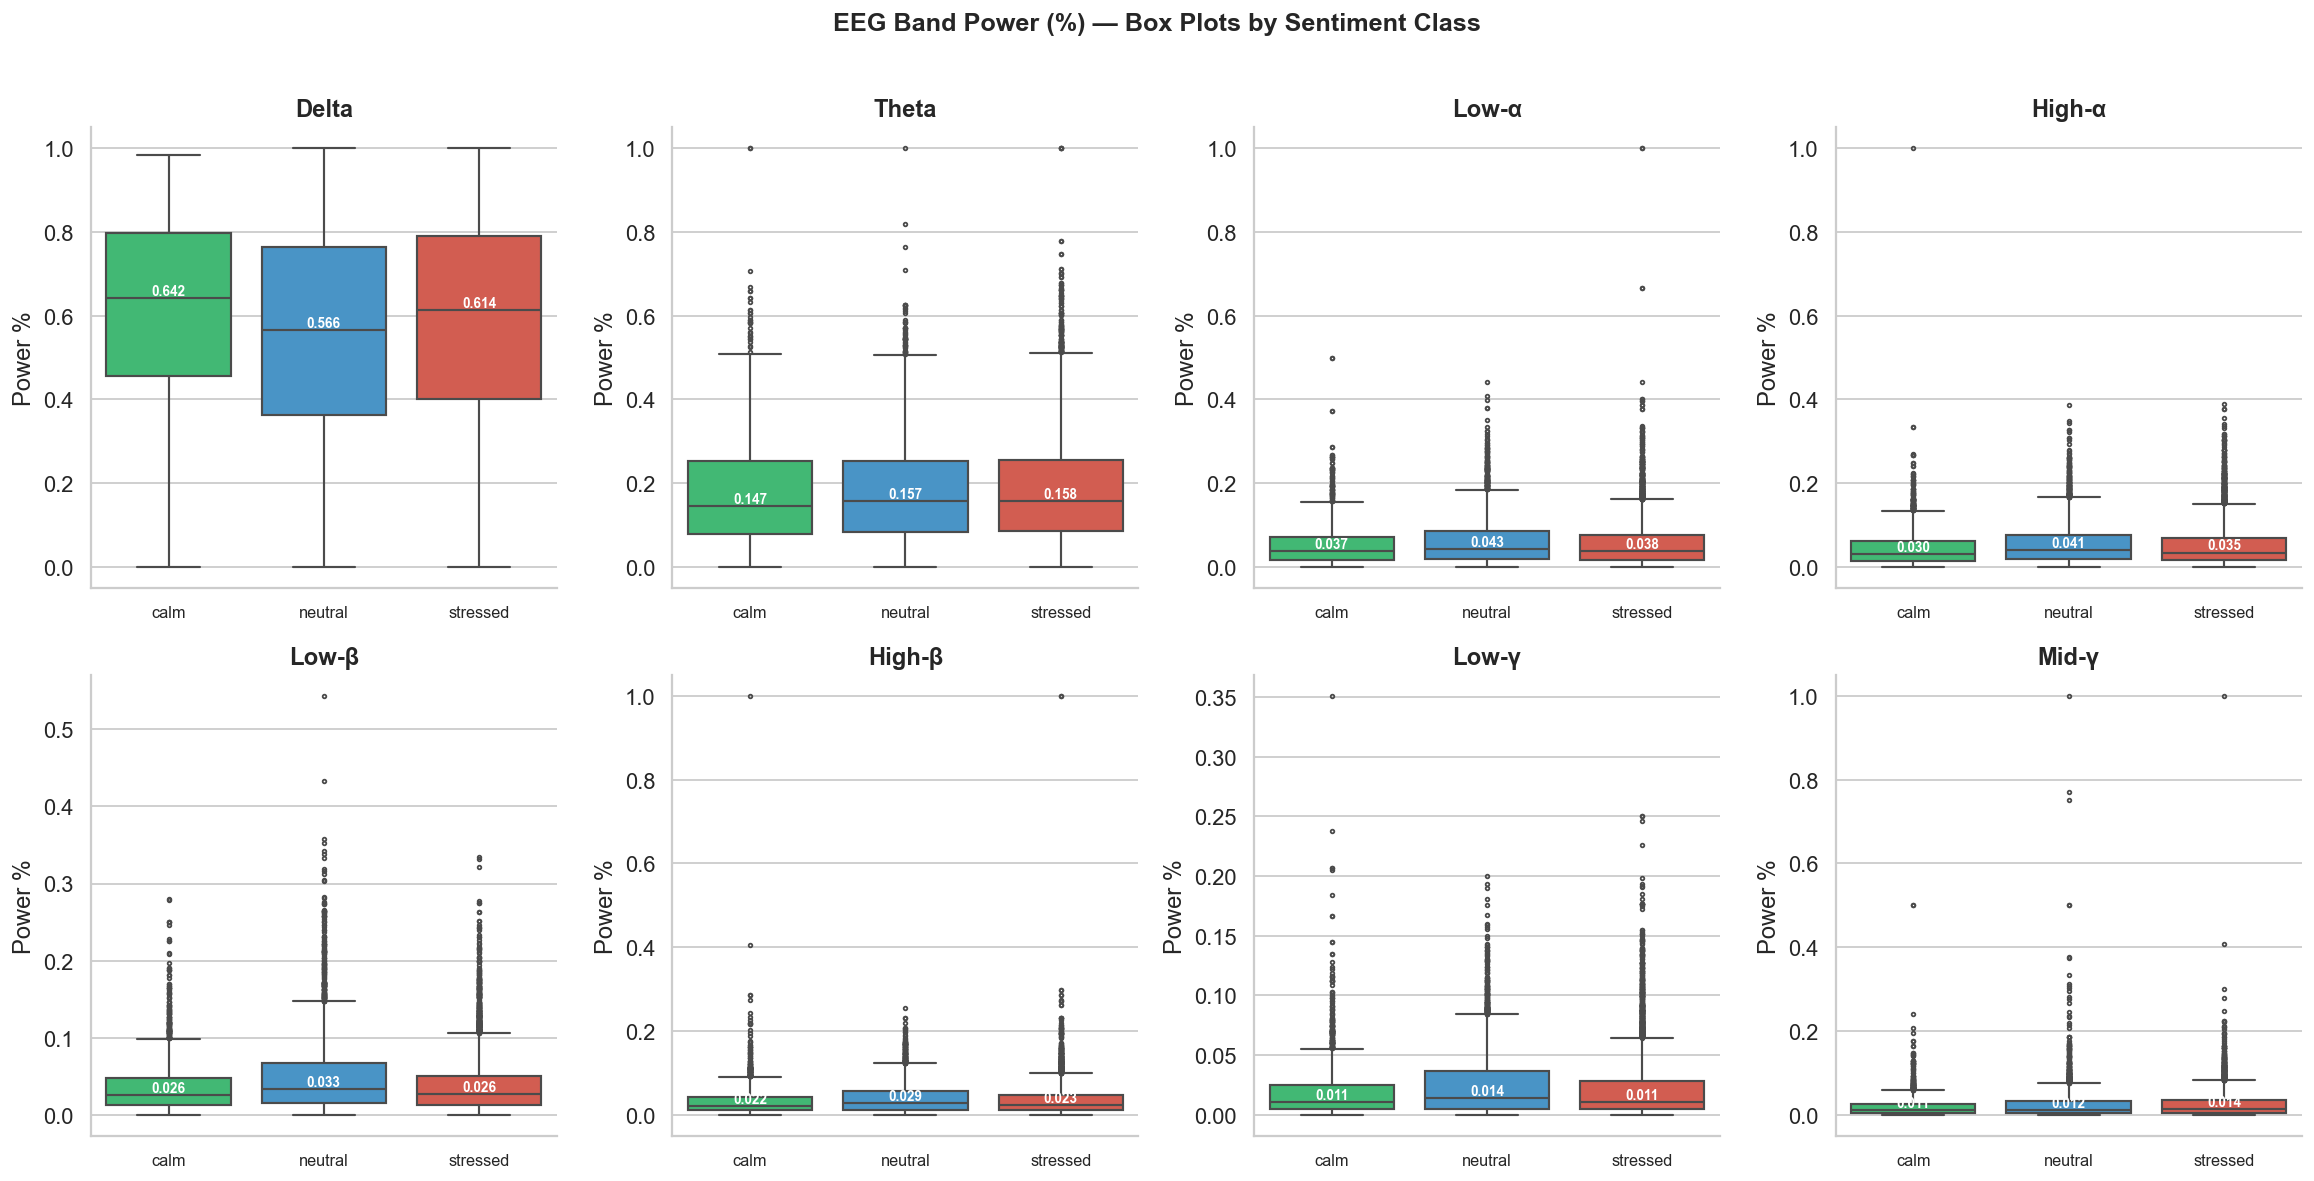

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, col, label in zip(axes, BAND_COLS, BAND_LABELS):
    sns.boxplot(
        data=df, x="label_3class", y=col, order=CLASS_ORDER,
        palette=CLASS_COLORS, fliersize=2, linewidth=1.2, ax=ax
    )
    # Overlay class medians as text
    for i, cls in enumerate(CLASS_ORDER):
        med = df.loc[df["label_3class"] == cls, col].median()
        ax.text(i, med, f"{med:.3f}", ha="center", va="bottom",
                fontsize=7.5, color="white", fontweight="bold")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Power %")
    ax.tick_params(axis="x", labelsize=9)

plt.suptitle("EEG Band Power (%) — Box Plots by Sentiment Class",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 4c. Stacked Band Composition per Class — mean proportions

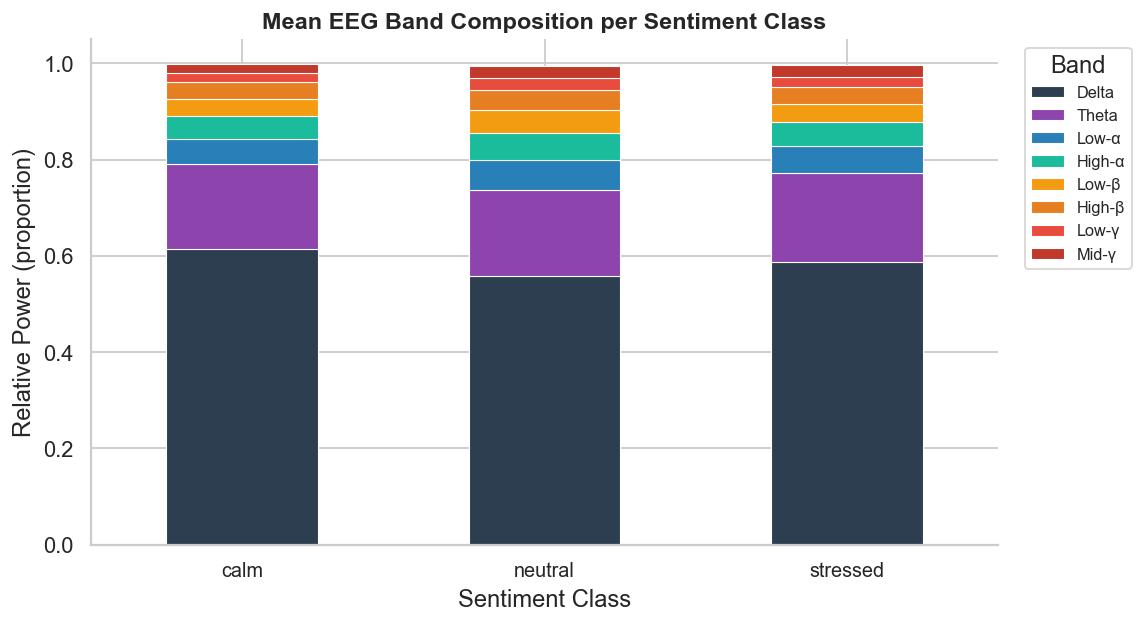


Mean band power per class:


,Delta,Theta,Low-α,High-α,Low-β,High-β,Low-γ,Mid-γ
label_3class,,,,,,,,
calm,0.6143,0.1769,0.0522,0.0464,0.0369,0.0334,0.0196,0.0199
neutral,0.5573,0.1802,0.0608,0.0558,0.0495,0.0401,0.0251,0.0254
stressed,0.5862,0.1850,0.0560,0.0512,0.0379,0.0343,0.0217,0.0251


In [8]:
band_means = df.groupby("label_3class", observed=True)[BAND_COLS].mean()
band_means.columns = BAND_LABELS

band_colors = ["#2c3e50", "#8e44ad", "#2980b9", "#1abc9c",
               "#f39c12", "#e67e22", "#e74c3c", "#c0392b"]

ax = band_means.plot(
    kind="bar", stacked=True,
    color=band_colors, figsize=(9, 5),
    edgecolor="white", linewidth=0.6
)
ax.set_title("Mean EEG Band Composition per Sentiment Class",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Sentiment Class")
ax.set_ylabel("Relative Power (proportion)")
ax.set_xticklabels(CLASS_ORDER, rotation=0, fontsize=11)
ax.legend(title="Band", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print("\nMean band power per class:")
band_means.round(4)

## 5. Attention & Meditation Deep-Dive

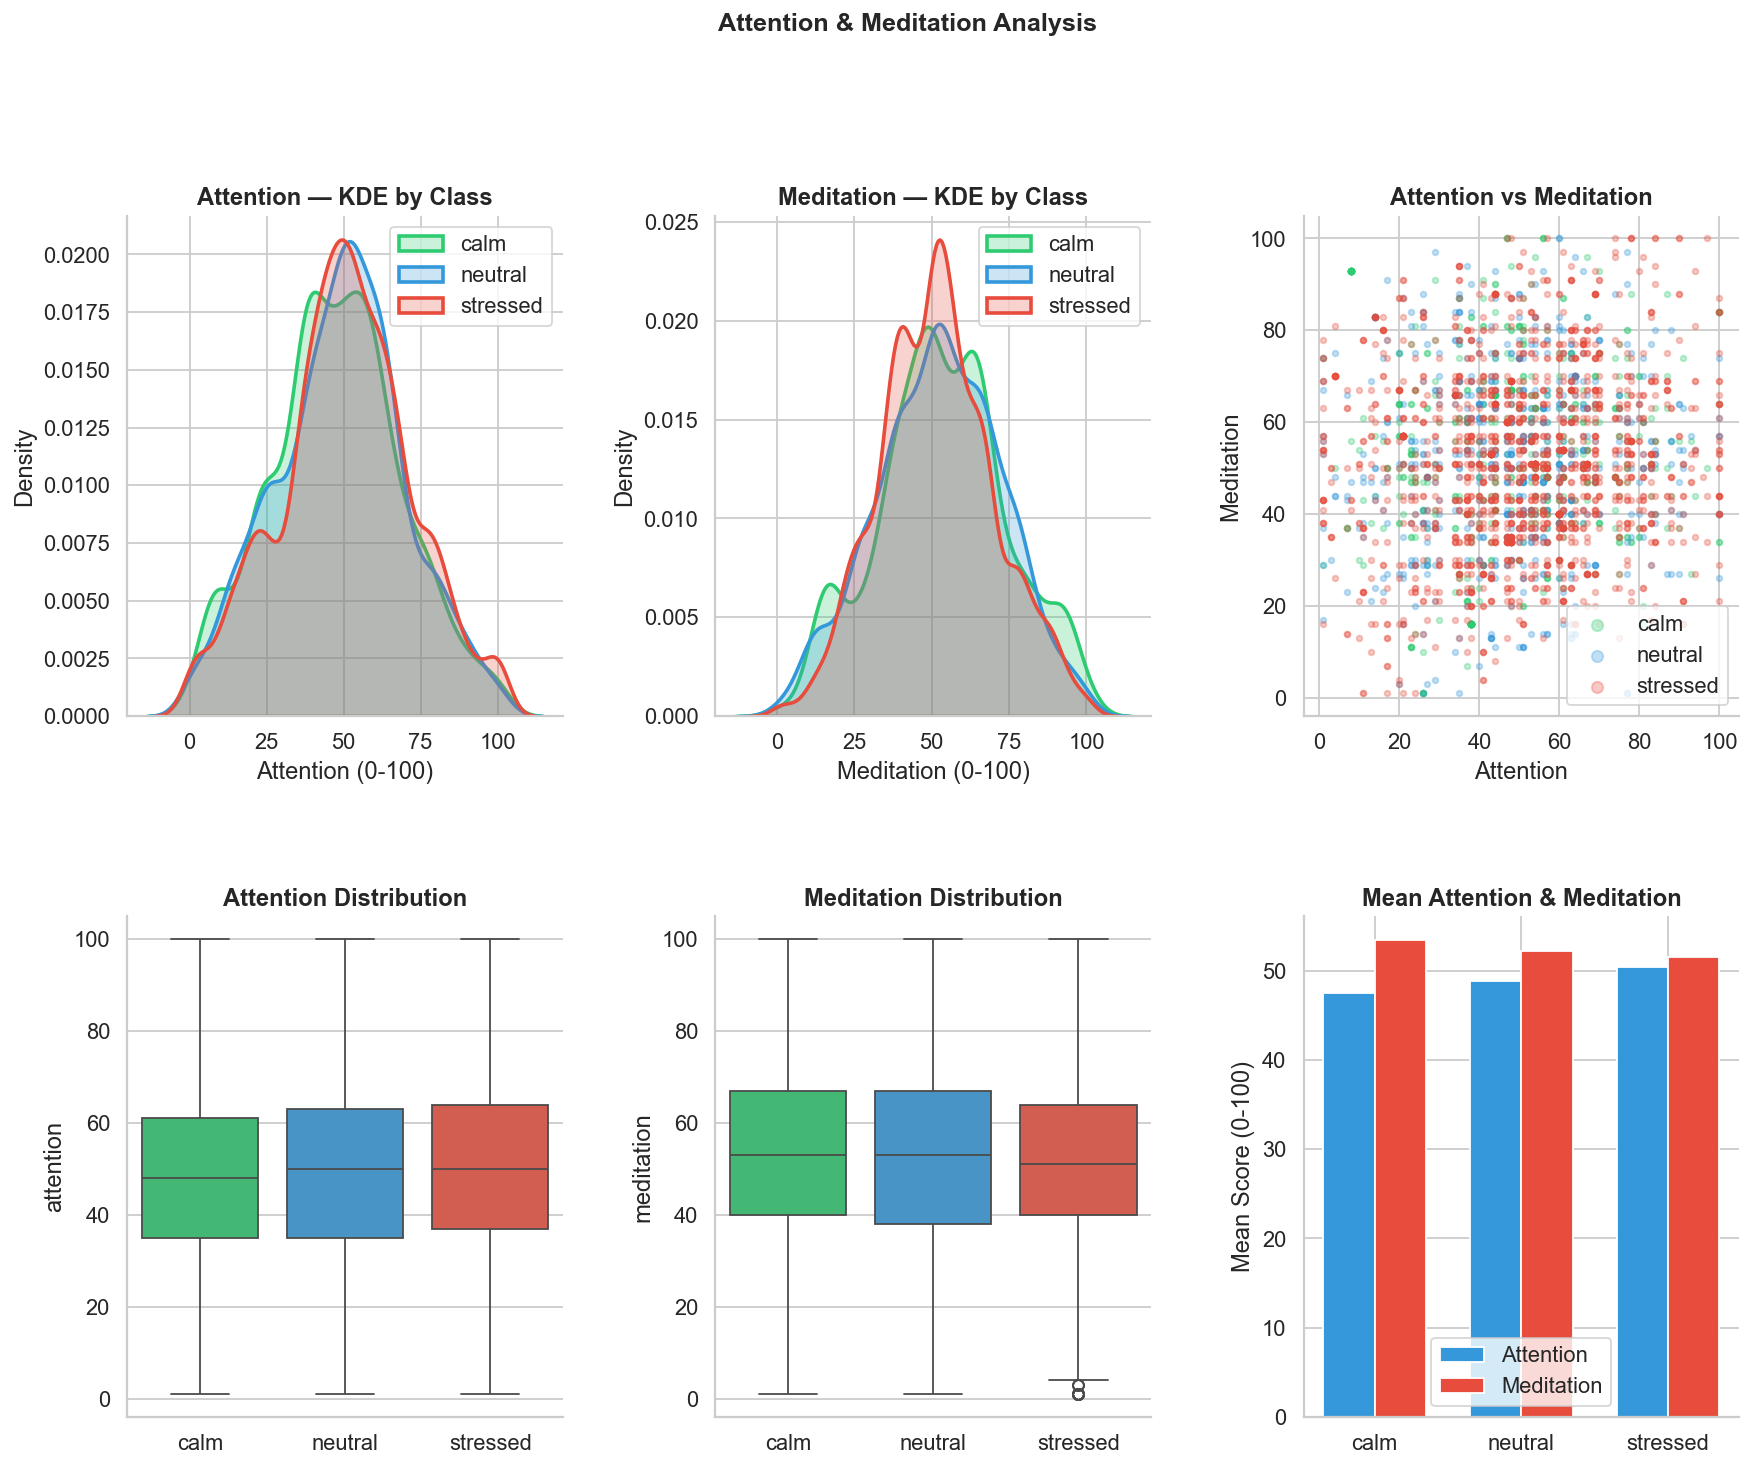

In [9]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── KDE per class ────────────────────────────────────────────────────────────
for col_idx, (feat, title) in enumerate([("attention", "Attention"), ("meditation", "Meditation")]):
    ax = fig.add_subplot(gs[0, col_idx])
    for cls in CLASS_ORDER:
        subset = df.loc[df["label_3class"] == cls, feat].dropna()
        subset = subset[subset > 0]  # exclude no-signal zeros
        sns.kdeplot(subset, ax=ax, label=cls, color=CLASS_COLORS[cls],
                    fill=True, alpha=0.25, linewidth=2)
    ax.set_title(f"{title} — KDE by Class", fontweight="bold")
    ax.set_xlabel(title + " (0-100)")
    ax.legend()

# ── Scatter: Attention vs Meditation ────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
sample = df[df[["attention", "meditation"]].gt(0).all(axis=1)].sample(min(3000, len(df)), random_state=42)
for cls in CLASS_ORDER:
    sub = sample[sample["label_3class"] == cls]
    ax.scatter(sub["attention"], sub["meditation"],
               c=CLASS_COLORS[cls], label=cls, alpha=0.3, s=10, rasterized=True)
ax.set_title("Attention vs Meditation", fontweight="bold")
ax.set_xlabel("Attention")
ax.set_ylabel("Meditation")
ax.legend(markerscale=2)

# ── Box: Attention by Class ──────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
valid = df[df["attention"] > 0]
sns.boxplot(data=valid, x="label_3class", y="attention",
            order=CLASS_ORDER, palette=CLASS_COLORS, ax=ax)
ax.set_title("Attention Distribution", fontweight="bold")
ax.set_xlabel("")

# ── Box: Meditation by Class ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
valid = df[df["meditation"] > 0]
sns.boxplot(data=valid, x="label_3class", y="meditation",
            order=CLASS_ORDER, palette=CLASS_COLORS, ax=ax)
ax.set_title("Meditation Distribution", fontweight="bold")
ax.set_xlabel("")

# ── Mean Attention & Meditation bar ─────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
means = df[df[["attention","meditation"]].gt(0).all(axis=1)].groupby(
    "label_3class", observed=True)[["attention", "meditation"]].mean().reindex(CLASS_ORDER)
x = np.arange(len(CLASS_ORDER))
w = 0.35
ax.bar(x - w/2, means["attention"], w, label="Attention", color="#3498db", edgecolor="white")
ax.bar(x + w/2, means["meditation"], w, label="Meditation", color="#e74c3c", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(CLASS_ORDER)
ax.set_title("Mean Attention & Meditation", fontweight="bold")
ax.set_ylabel("Mean Score (0-100)")
ax.legend()

plt.suptitle("Attention & Meditation Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.show()

## 6. Frequency Band Radar Charts

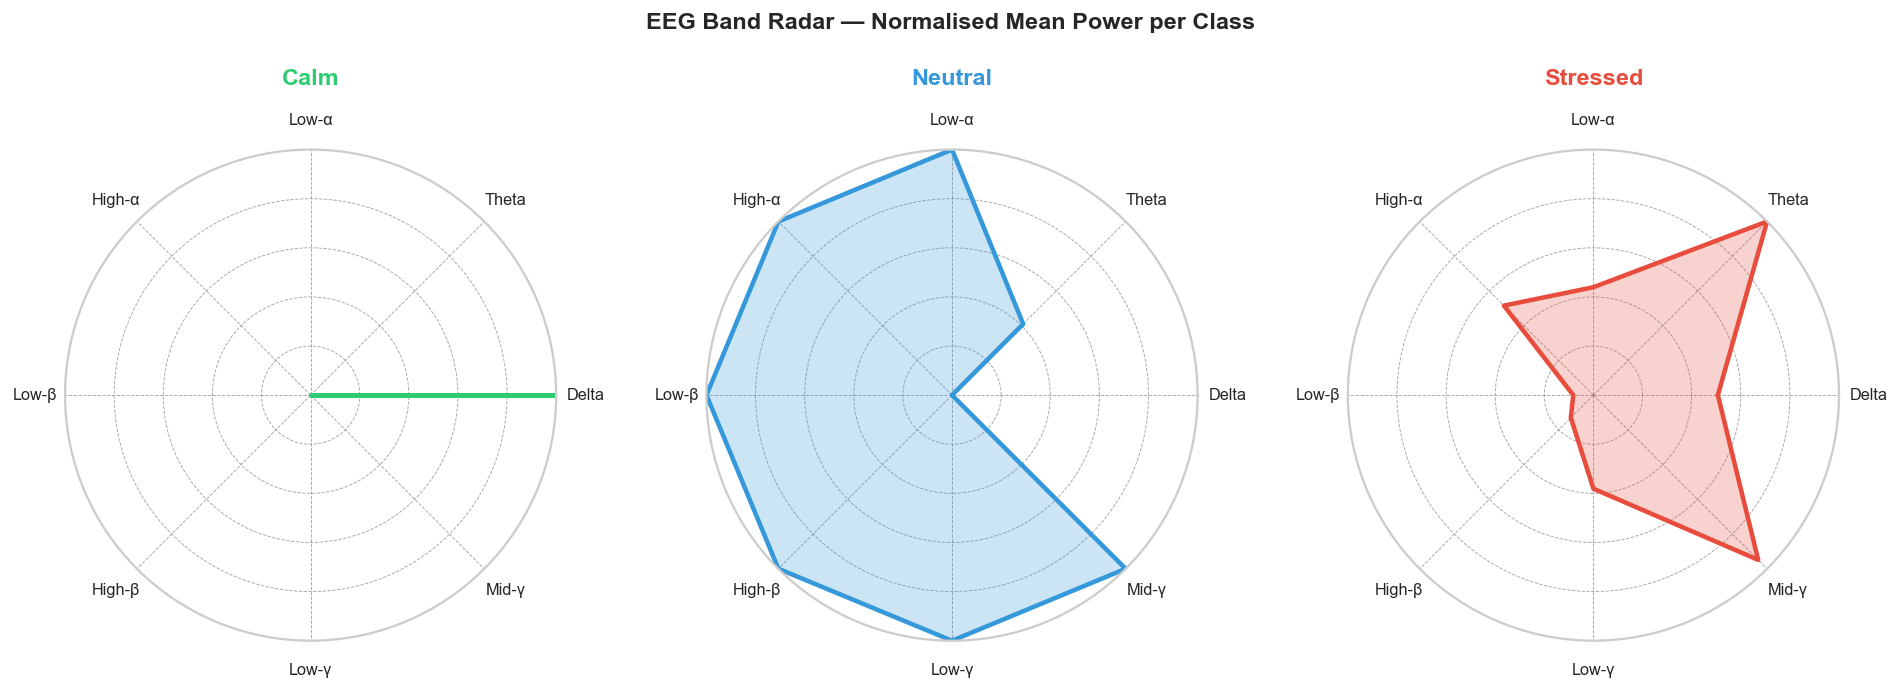

In [10]:
band_means_norm = band_means.copy()
# Normalise each band to [0,1] across classes for fair radar shape
for col in band_means_norm.columns:
    mn, mx = band_means_norm[col].min(), band_means_norm[col].max()
    if mx > mn:
        band_means_norm[col] = (band_means_norm[col] - mn) / (mx - mn)

N = len(BAND_LABELS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close circle

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw=dict(polar=True))

for ax, cls in zip(axes, CLASS_ORDER):
    vals = band_means_norm.loc[cls].tolist() + band_means_norm.loc[cls].tolist()[:1]
    ax.plot(angles, vals, color=CLASS_COLORS[cls], linewidth=2.5)
    ax.fill(angles, vals, color=CLASS_COLORS[cls], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(BAND_LABELS, fontsize=9)
    ax.set_yticklabels([])
    ax.set_title(cls.capitalize(), fontweight="bold", pad=15, fontsize=13,
                 color=CLASS_COLORS[cls])
    ax.set_ylim(0, 1)
    ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.7)

plt.suptitle("EEG Band Radar — Normalised Mean Power per Class",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

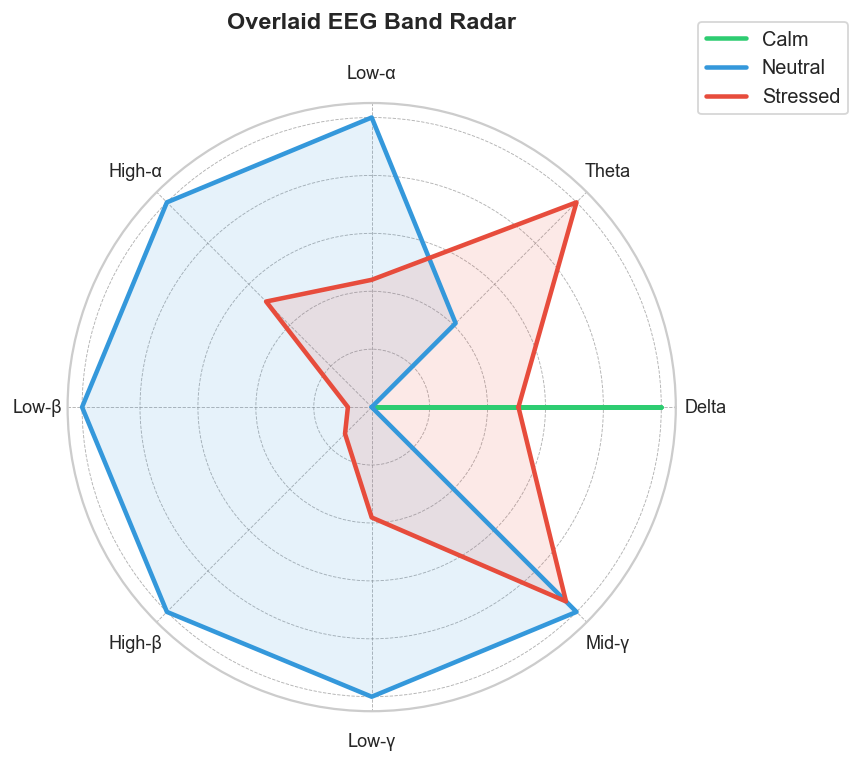

In [11]:
# Overlay radar (all 3 classes on one chart)
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for cls in CLASS_ORDER:
    vals = band_means_norm.loc[cls].tolist() + band_means_norm.loc[cls].tolist()[:1]
    ax.plot(angles, vals, color=CLASS_COLORS[cls], linewidth=2.5, label=cls.capitalize())
    ax.fill(angles, vals, color=CLASS_COLORS[cls], alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(BAND_LABELS, fontsize=10)
ax.set_yticklabels([])
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), fontsize=11)
ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_title("Overlaid EEG Band Radar", fontweight="bold", fontsize=13, pad=20)
plt.tight_layout()
plt.show()

## 7. Derived Ratios — Theta/Beta, Alpha/Beta, Slow/Fast

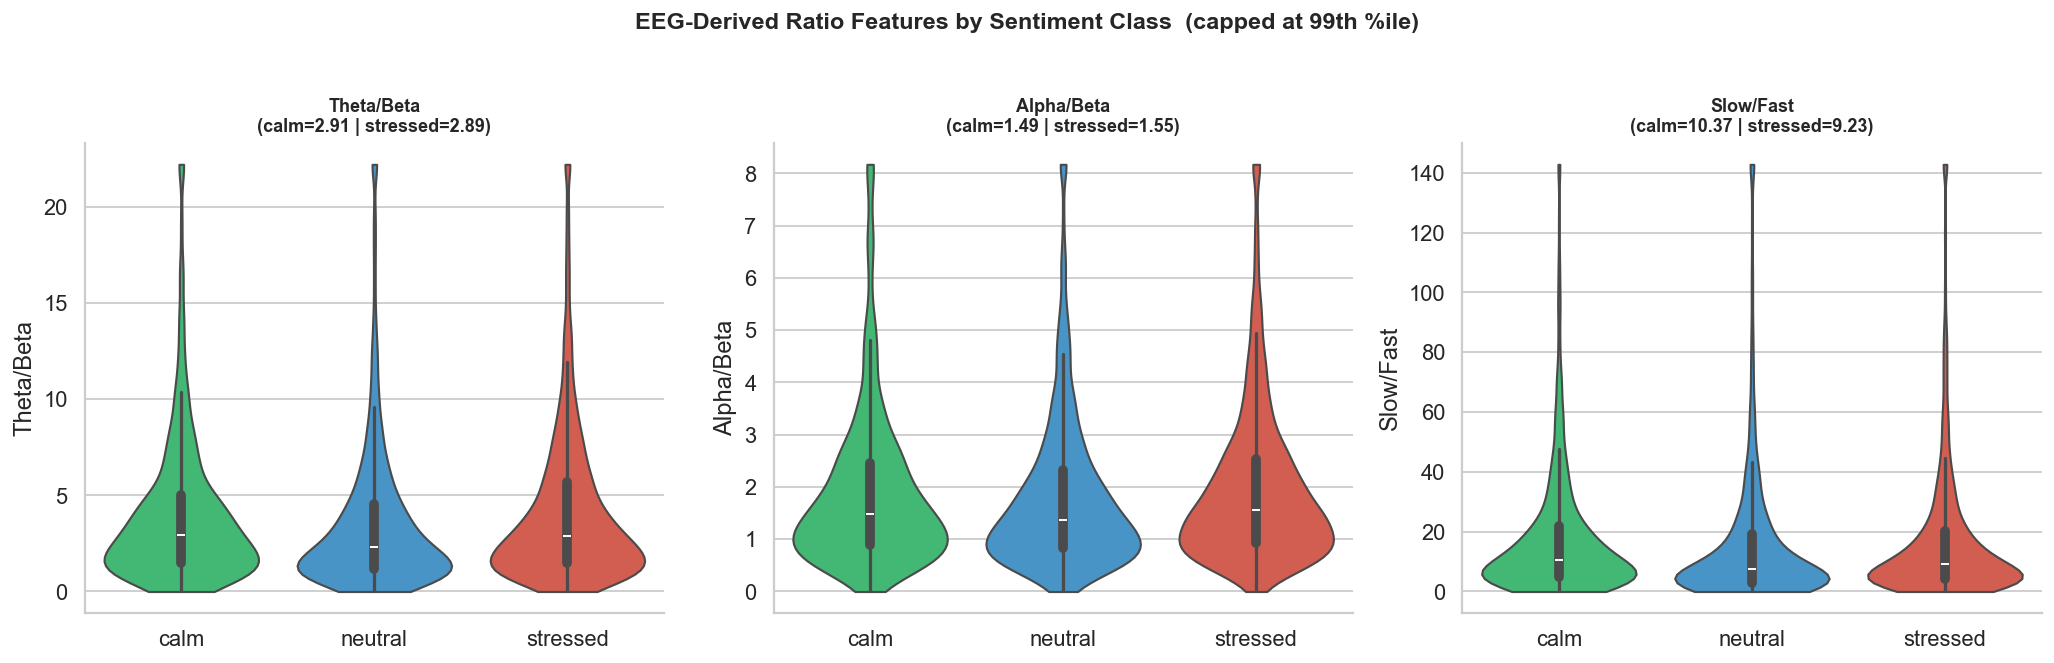

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, label in zip(axes, RATIO_COLS, RATIO_LABELS):
    # Cap extreme outliers at 99th percentile for display
    cap = df[col].quantile(0.99)
    data_capped = df[col].clip(upper=cap)
    temp = df.copy()
    temp[col] = data_capped
    
    sns.violinplot(
        data=temp, x="label_3class", y=col, order=CLASS_ORDER,
        palette=CLASS_COLORS, inner="box", cut=0,
        linewidth=1.2, ax=ax
    )
    # Significance annotation bar between stressed and calm
    calm_med   = df.loc[df["label_3class"] == "calm", col].median()
    stress_med = df.loc[df["label_3class"] == "stressed", col].median()
    ax.set_title(f"{label}\n(calm={calm_med:.2f} | stressed={stress_med:.2f})",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel(label)

plt.suptitle("EEG-Derived Ratio Features by Sentiment Class  (capped at 99th %ile)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Rolling Statistics — Temporal Stability

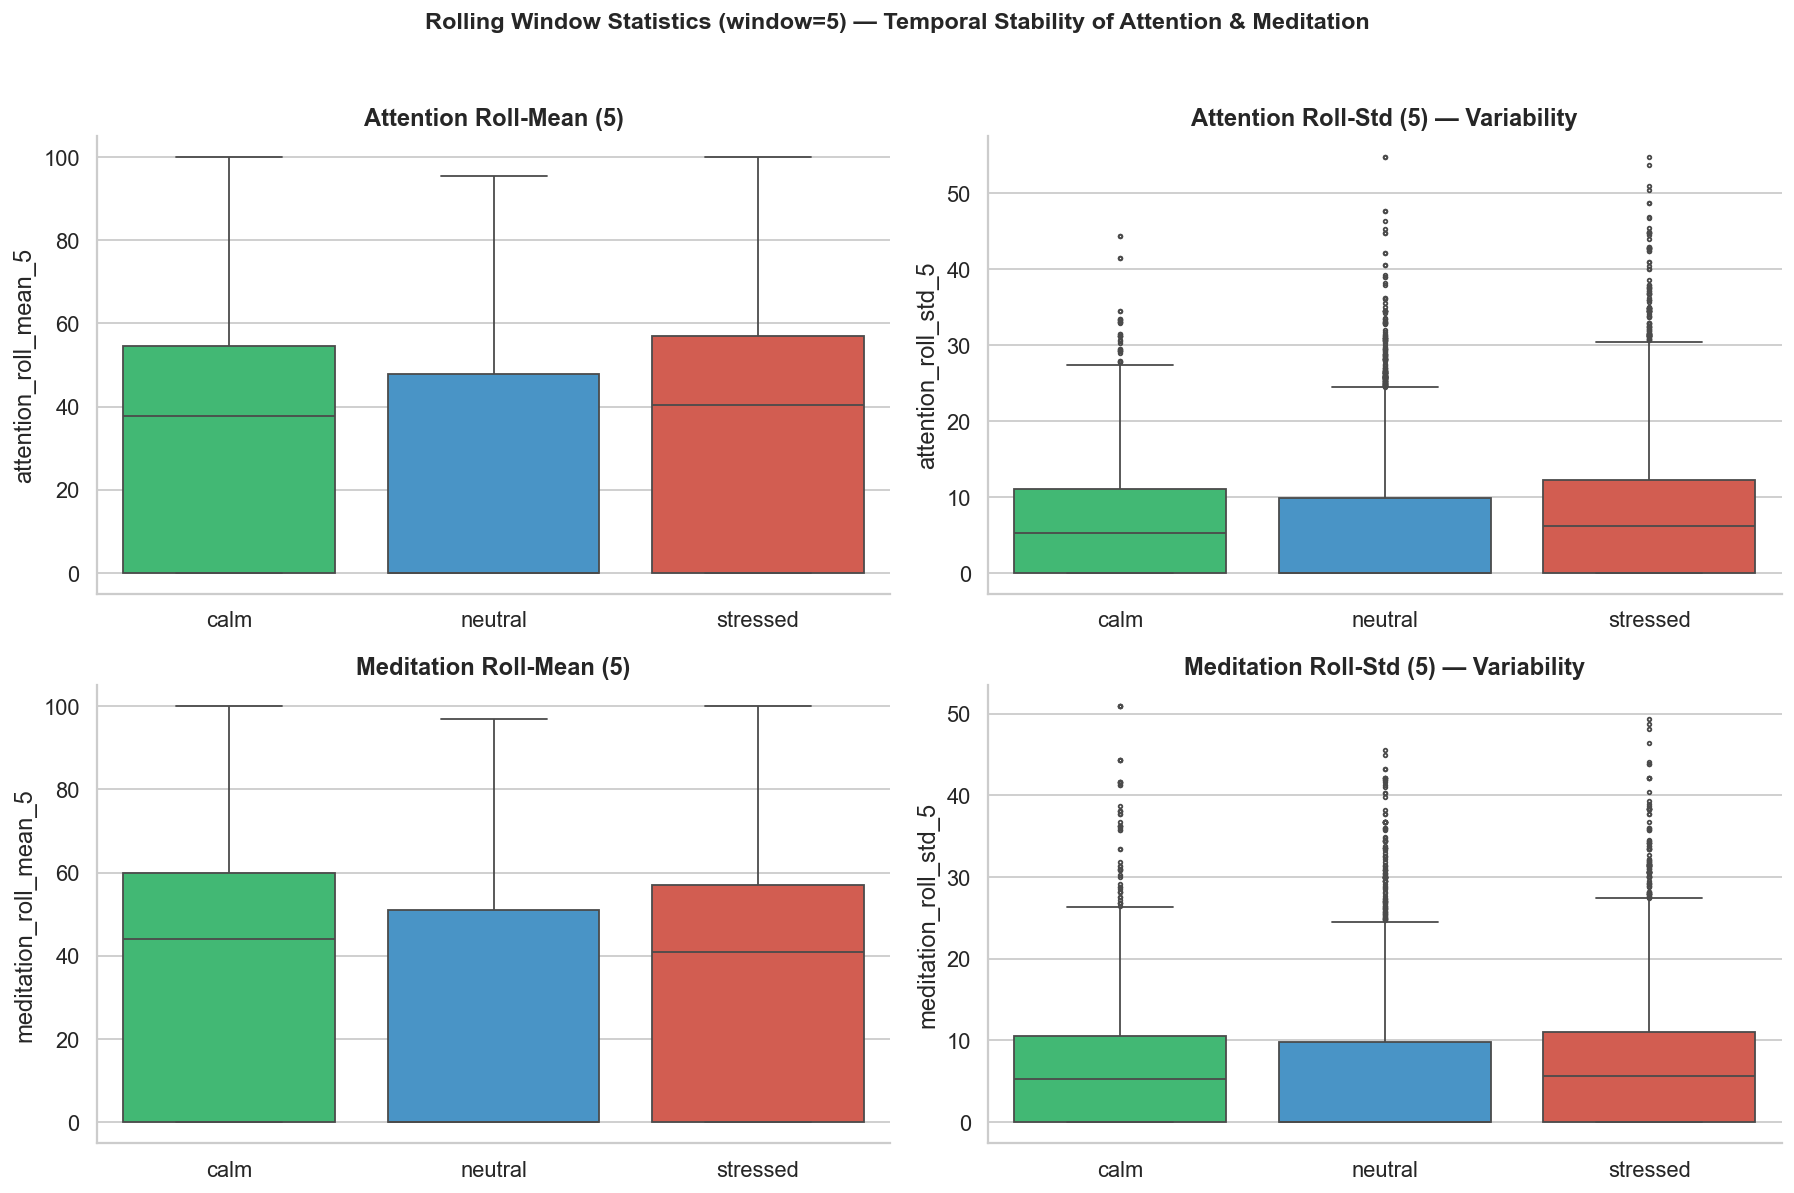

In [13]:
roll_mean_cols = [c for c in df.columns if c.endswith("_roll_mean_5")]
roll_std_cols  = [c for c in df.columns if c.endswith("_roll_std_5")]

# Plot mean attention / meditation rolling stats per class
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

features = [
    ("attention_roll_mean_5",    "Attention Roll-Mean (5)"),
    ("attention_roll_std_5",     "Attention Roll-Std (5) — Variability"),
    ("meditation_roll_mean_5",   "Meditation Roll-Mean (5)"),
    ("meditation_roll_std_5",    "Meditation Roll-Std (5) — Variability"),
]

for ax, (col, title) in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="label_3class", y=col, order=CLASS_ORDER,
                palette=CLASS_COLORS, fliersize=2, ax=ax)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("Rolling Window Statistics (window=5) — Temporal Stability of Attention & Meditation",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

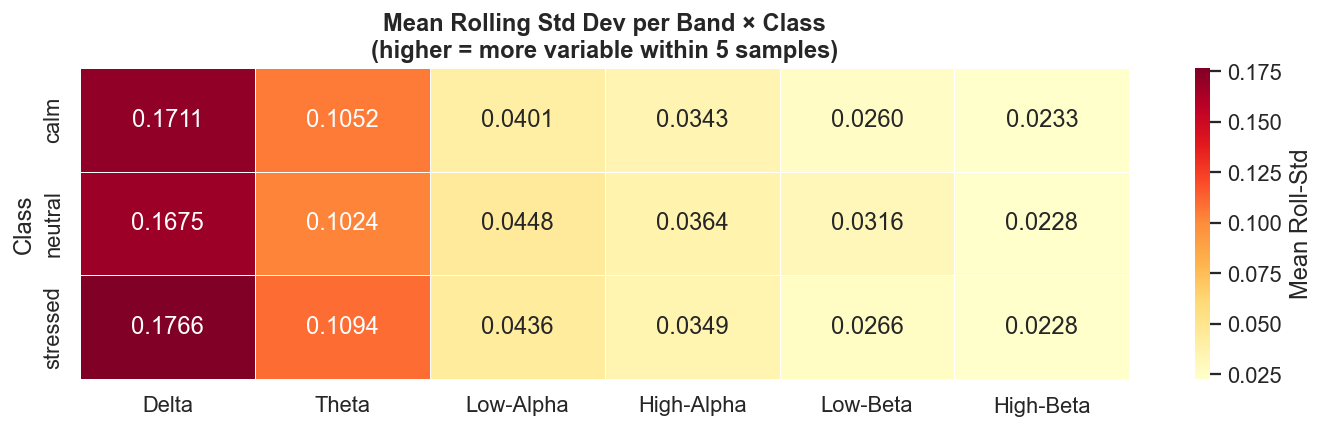

In [14]:
# Rolling std heatmap — which bands are most stable per class?
roll_std_bands = [c for c in roll_std_cols if "attention" not in c and "meditation" not in c]
nice_names      = [c.replace("_pct_roll_std_5", "").replace("_", "-").title() for c in roll_std_bands]

mean_std = df.groupby("label_3class", observed=True)[roll_std_bands].mean().reindex(CLASS_ORDER)
mean_std.columns = nice_names

fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(mean_std, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Mean Roll-Std"})
ax.set_title("Mean Rolling Std Dev per Band × Class\n(higher = more variable within 5 samples)",
             fontweight="bold")
ax.set_ylabel("Class")
plt.tight_layout()
plt.show()

## 9. Correlation Heatmap

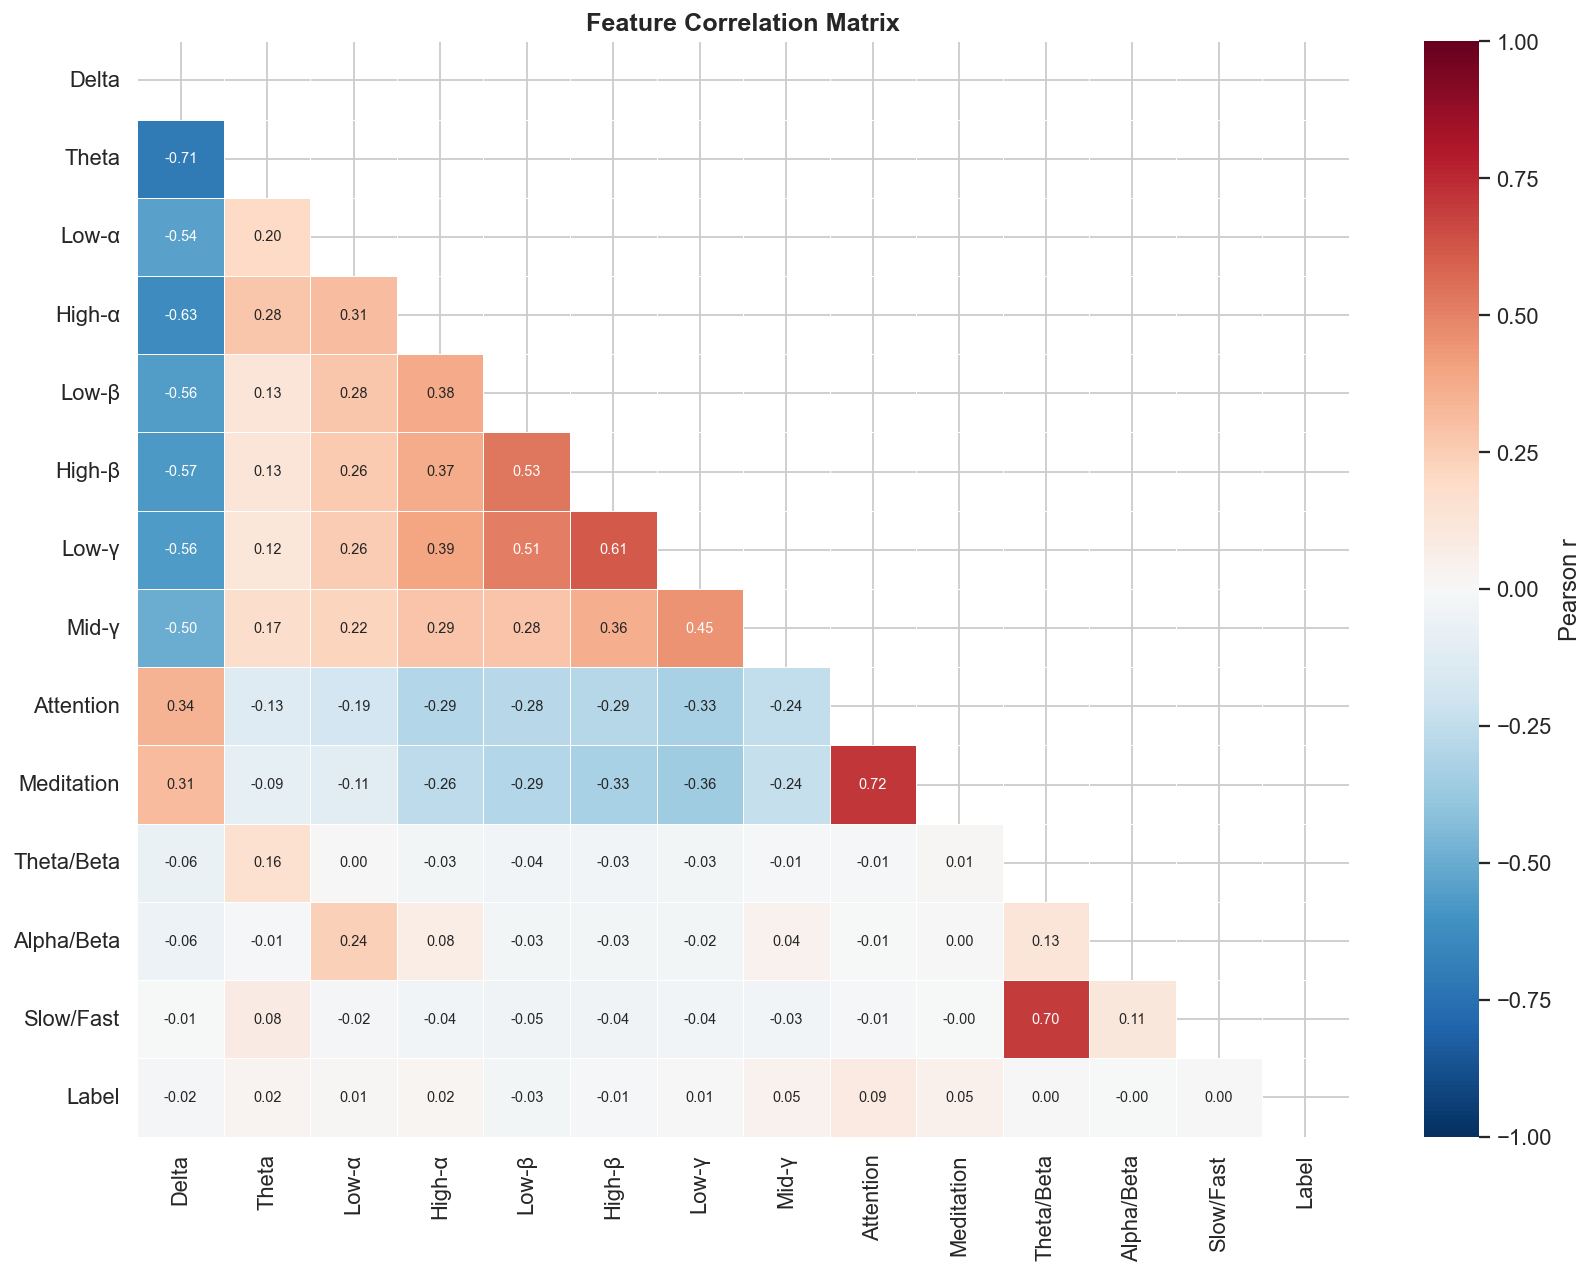

Top features correlated with label_encoded:
Attention     0.091950
Meditation    0.053408
Mid-γ         0.046130
Low-β         0.030831
Theta         0.024850
Delta         0.019917
High-α        0.017460
High-β        0.014072
Low-α         0.008993
Low-γ         0.006776


In [15]:
core_cols = BAND_COLS + ["attention", "meditation"] + RATIO_COLS + ["label_encoded"]
corr = df[core_cols].corr()

nice = BAND_LABELS + ["Attention", "Meditation"] + RATIO_LABELS + ["Label"]
corr.index = nice
corr.columns = nice

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.4, annot_kws={"size": 8},
    ax=ax, cbar_kws={"label": "Pearson r"}
)
ax.set_title("Feature Correlation Matrix", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with label
print("Top features correlated with label_encoded:")
print(corr["Label"].drop("Label").abs().sort_values(ascending=False).head(10).to_string())

## 10. Time-Series for a Single Session

Session: 0091  |  Rows: 976  |  Duration: 870s


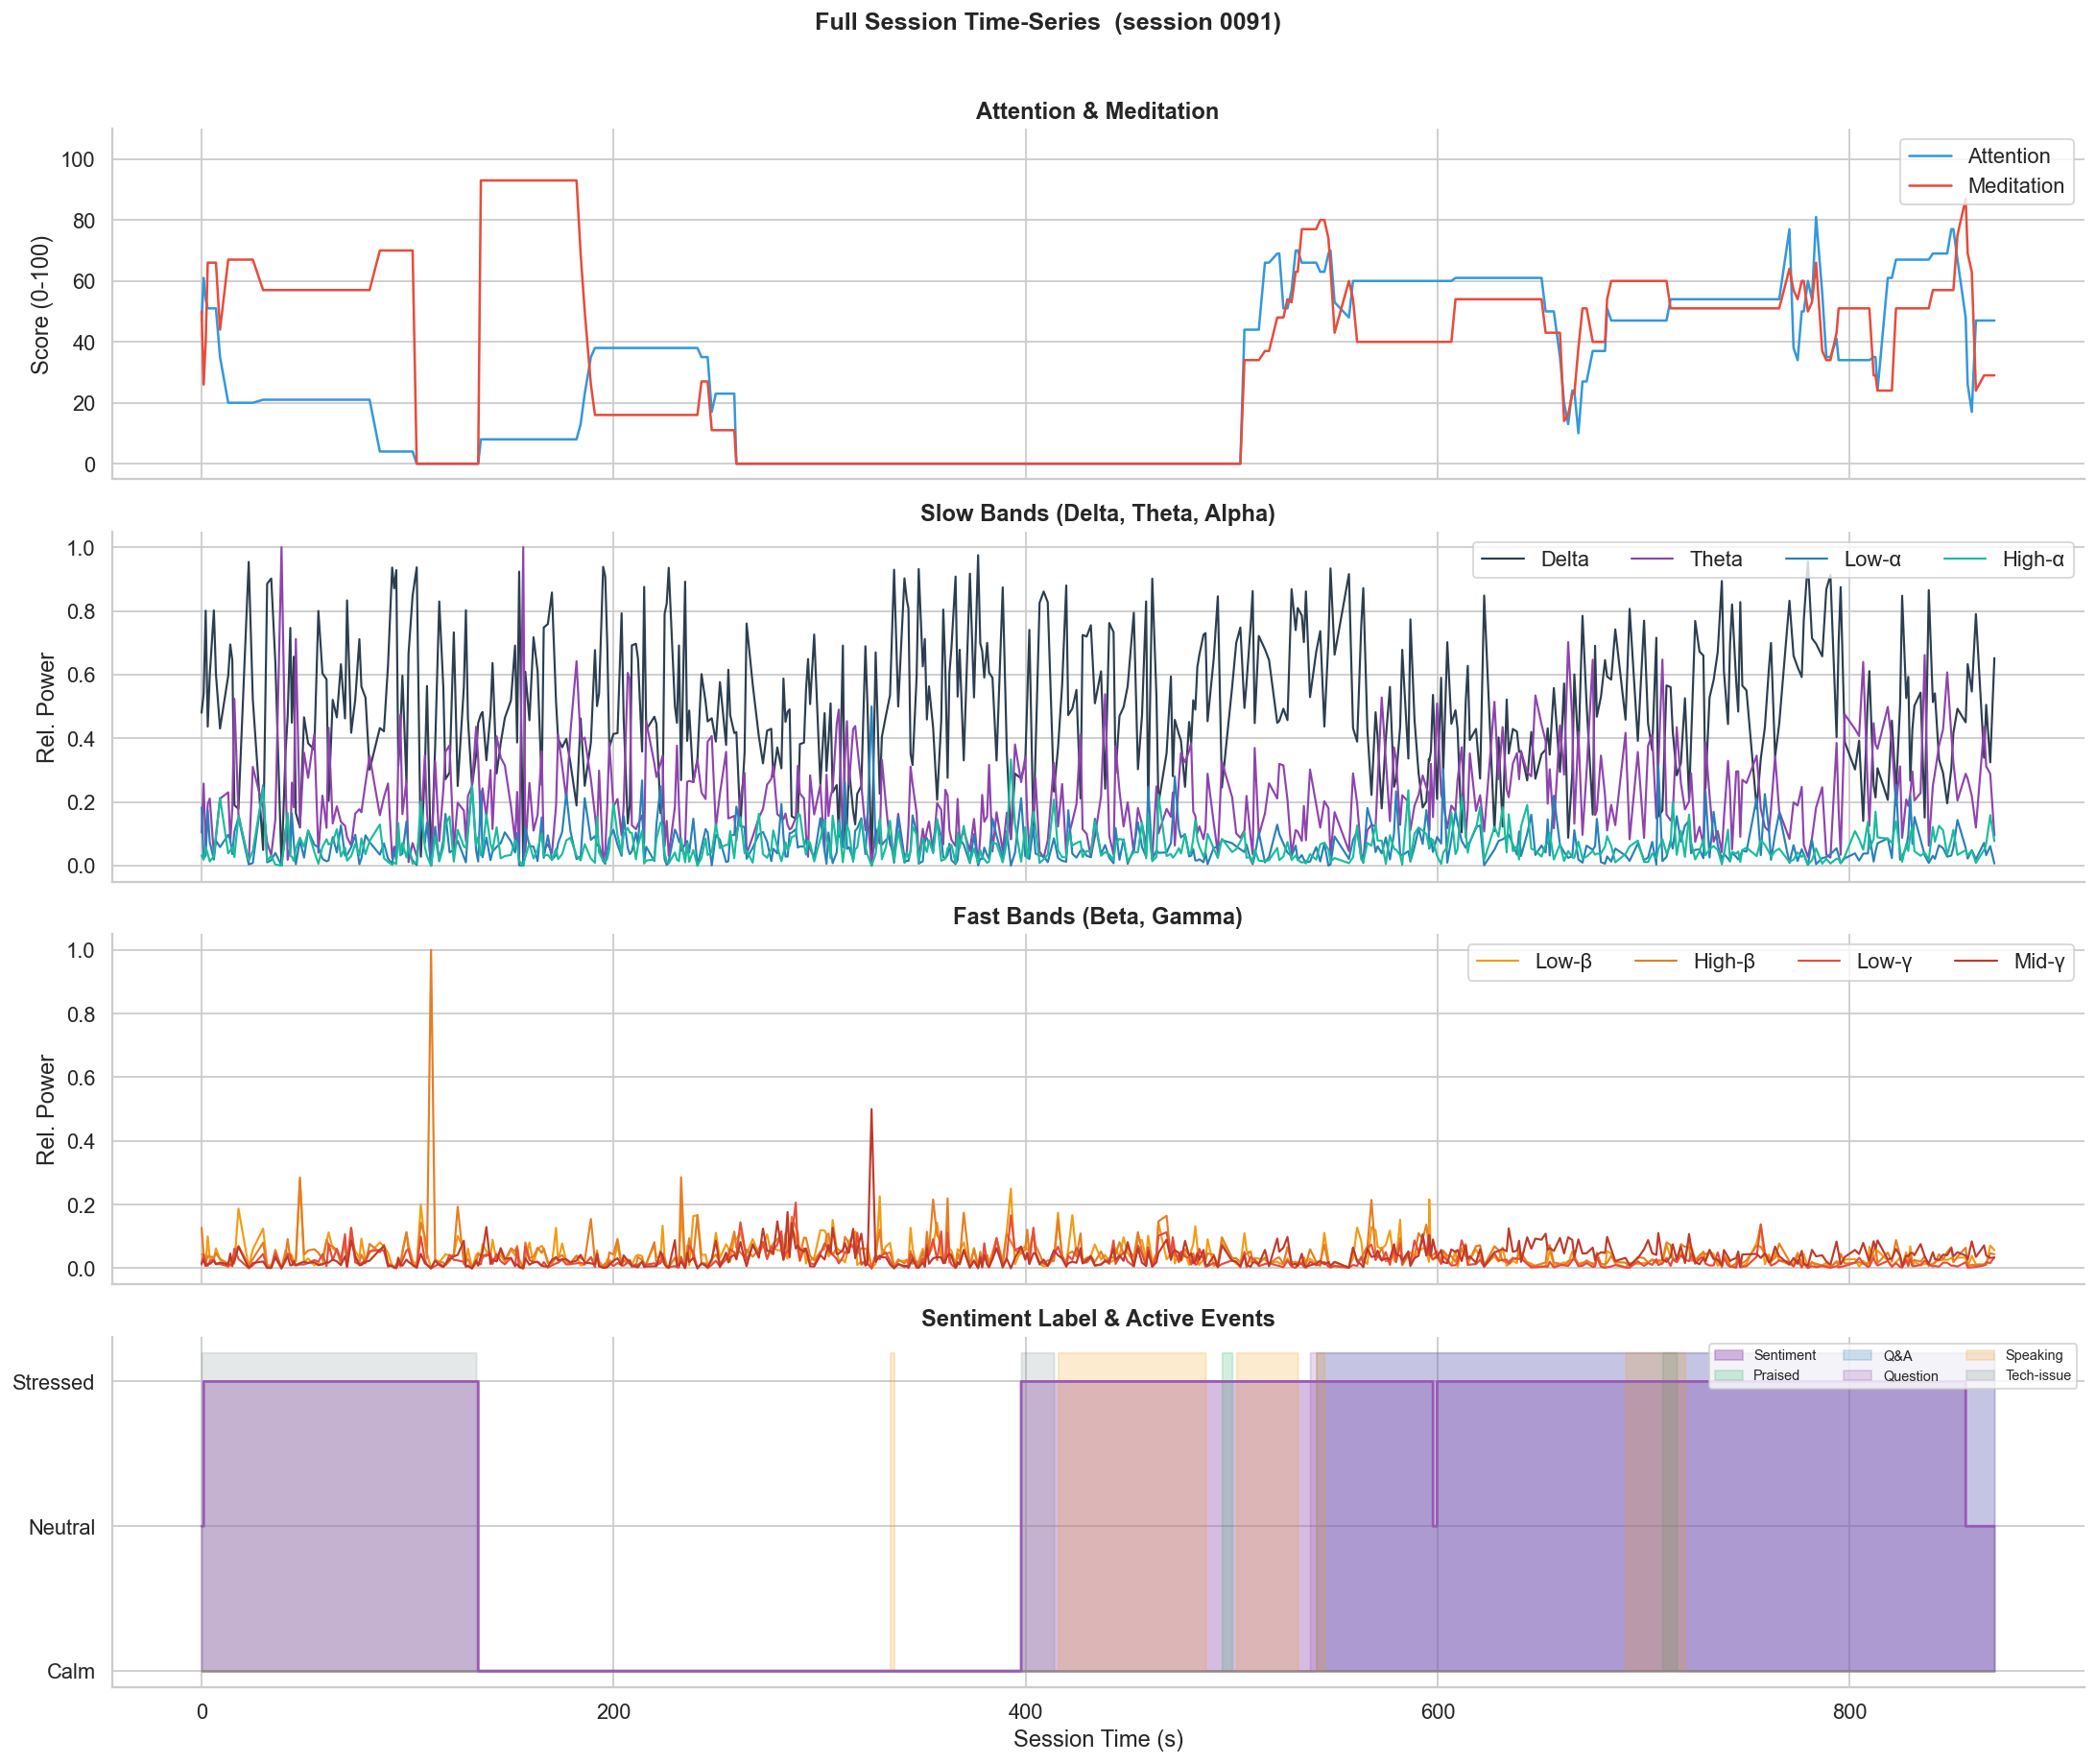

In [16]:
# Pick session with most rows
target_session = df["session_id"].value_counts().idxmax()
sess = df[df["session_id"] == target_session].sort_values("session_time_sec").reset_index(drop=True)
print(f"Session: {target_session}  |  Rows: {len(sess)}  |  Duration: {sess['session_time_sec'].max():.0f}s")

fig, axes = plt.subplots(4, 1, figsize=(17, 14), sharex=True)

t = sess["session_time_sec"]

# ── Panel 1: Attention & Meditation ─────────────────────────────────────────
ax = axes[0]
ax.plot(t, sess["attention"],  label="Attention",  color="#3498db", linewidth=1.4)
ax.plot(t, sess["meditation"], label="Meditation", color="#e74c3c", linewidth=1.4)
ax.set_ylabel("Score (0-100)")
ax.set_title("Attention & Meditation", fontweight="bold")
ax.legend(loc="upper right")
ax.set_ylim(-5, 110)

# ── Panel 2: Band power (slow bands) ────────────────────────────────────────
ax = axes[1]
slow = [("delta_pct", "Delta", "#2c3e50"), ("theta_pct", "Theta", "#8e44ad"),
        ("low_alpha_pct", "Low-α", "#2980b9"), ("high_alpha_pct", "High-α", "#1abc9c")]
for col, lbl, clr in slow:
    ax.plot(t, sess[col], label=lbl, color=clr, linewidth=1.2)
ax.set_ylabel("Rel. Power")
ax.set_title("Slow Bands (Delta, Theta, Alpha)", fontweight="bold")
ax.legend(loc="upper right", ncol=4)

# ── Panel 3: Fast bands ──────────────────────────────────────────────────────
ax = axes[2]
fast = [("low_beta_pct", "Low-β", "#f39c12"), ("high_beta_pct", "High-β", "#e67e22"),
        ("low_gamma_pct", "Low-γ", "#e74c3c"), ("mid_gamma_pct", "Mid-γ", "#c0392b")]
for col, lbl, clr in fast:
    ax.plot(t, sess[col], label=lbl, color=clr, linewidth=1.2)
ax.set_ylabel("Rel. Power")
ax.set_title("Fast Bands (Beta, Gamma)", fontweight="bold")
ax.legend(loc="upper right", ncol=4)

# ── Panel 4: Label & Events ──────────────────────────────────────────────────
ax = axes[3]
label_num = sess["label_encoded"]  # 0=calm,1=neutral,2=stressed
ax.fill_between(t, label_num, step="post", alpha=0.4, color="#9b59b6", label="Sentiment")
ax.step(t, label_num, where="post", color="#9b59b6", linewidth=1.5)
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(["Calm", "Neutral", "Stressed"])

# Overlay events as colored spans
ev_colors = ["#27ae60", "#2980b9", "#8e44ad", "#e74c3c", "#f39c12", "#7f8c8d"]
for ev_col, ev_lbl, ev_clr in zip(EVENT_COLS, EVENT_LABELS, ev_colors):
    if sess[ev_col].sum() > 0:
        ax.fill_between(t, 0, sess[ev_col] * 2.2,
                        alpha=0.2, color=ev_clr, step="post", label=ev_lbl)
ax.set_xlabel("Session Time (s)")
ax.set_title("Sentiment Label & Active Events", fontweight="bold")
ax.legend(loc="upper right", ncol=3, fontsize=8)

plt.suptitle(f"Full Session Time-Series  (session {target_session})",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 11. Event Marker Analysis

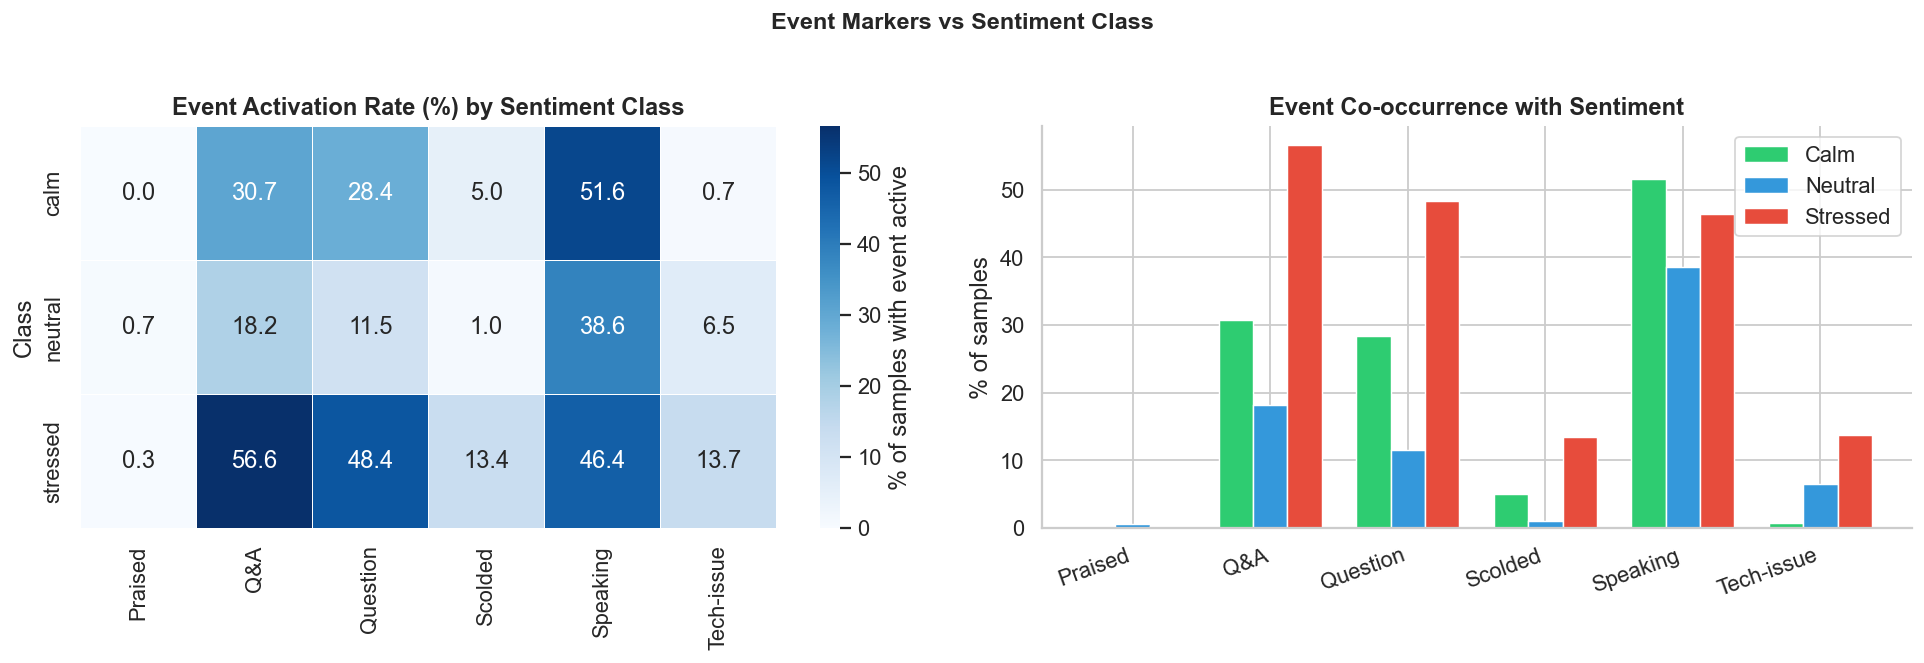

In [17]:
# Co-occurrence: events vs sentiment class
ev_class = df.groupby("label_3class", observed=True)[EVENT_COLS].mean().reindex(CLASS_ORDER)
ev_class.columns = EVENT_LABELS

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
ax = axes[0]
sns.heatmap(ev_class * 100, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.5, ax=ax, cbar_kws={"label": "% of samples with event active"})
ax.set_title("Event Activation Rate (%) by Sentiment Class", fontweight="bold")
ax.set_ylabel("Class")

# Grouped bar
ax = axes[1]
x = np.arange(len(EVENT_LABELS))
width = 0.25
for i, cls in enumerate(CLASS_ORDER):
    ax.bar(x + i * width, ev_class.loc[cls] * 100, width,
           label=cls.capitalize(), color=CLASS_COLORS[cls],
           edgecolor="white", linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(EVENT_LABELS, rotation=20, ha="right")
ax.set_ylabel("% of samples")
ax.set_title("Event Co-occurrence with Sentiment", fontweight="bold")
ax.legend()

plt.suptitle("Event Markers vs Sentiment Class", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

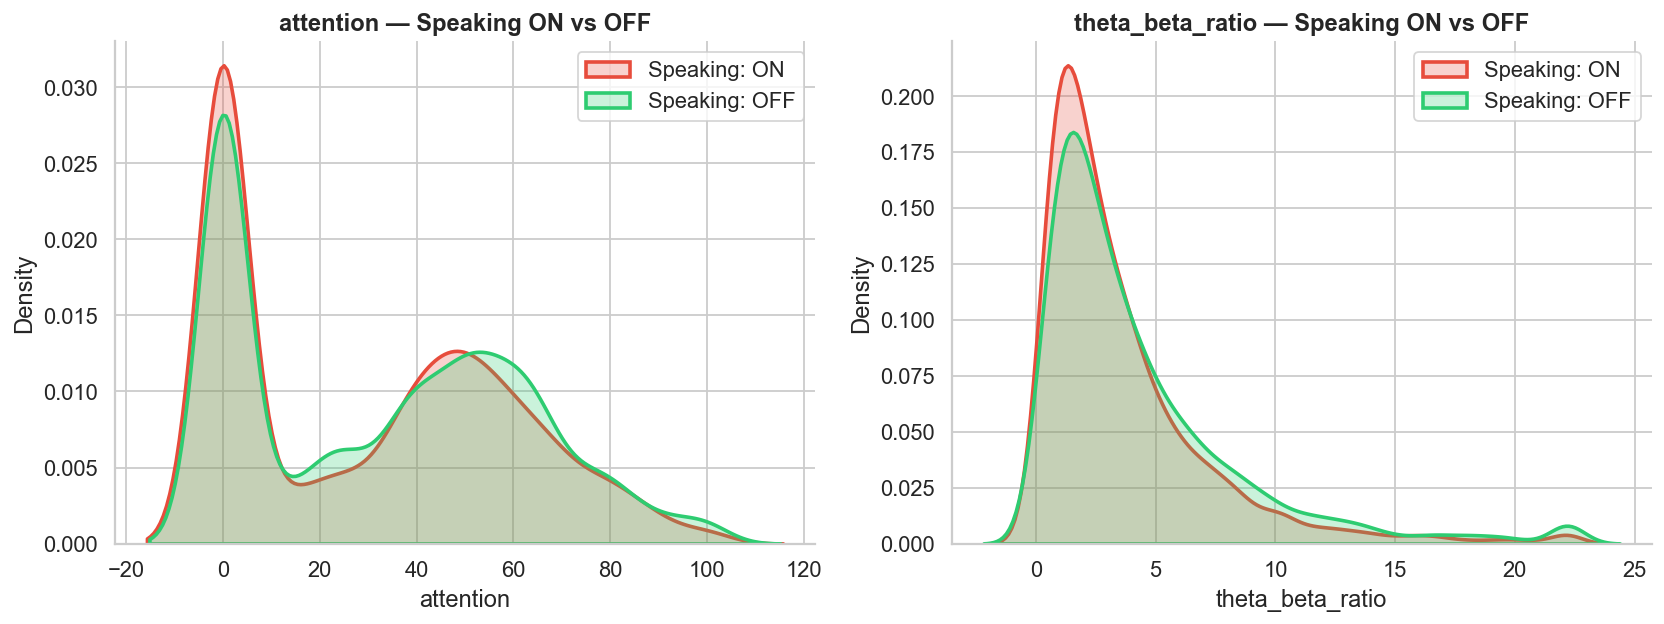

In [18]:
# EEG changes when a specific event is active vs inactive
EVENT_TO_INSPECT = "marker_ev_speaking_active"   # change as needed
ev_label = EVENT_TO_INSPECT.replace("marker_ev_", "").replace("_active", "").title()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ["attention", "theta_beta_ratio"]):
    active   = df.loc[df[EVENT_TO_INSPECT] == 1, metric].clip(upper=df[metric].quantile(0.99))
    inactive = df.loc[df[EVENT_TO_INSPECT] == 0, metric].clip(upper=df[metric].quantile(0.99))
    sns.kdeplot(active,   ax=ax, label=f"{ev_label}: ON",  color="#e74c3c", fill=True, alpha=0.25, linewidth=2)
    sns.kdeplot(inactive, ax=ax, label=f"{ev_label}: OFF", color="#2ecc71", fill=True, alpha=0.25, linewidth=2)
    ax.set_title(f"{metric} — {ev_label} ON vs OFF", fontweight="bold")
    ax.legend()

plt.tight_layout()
plt.show()

## 12. Signal Quality Analysis

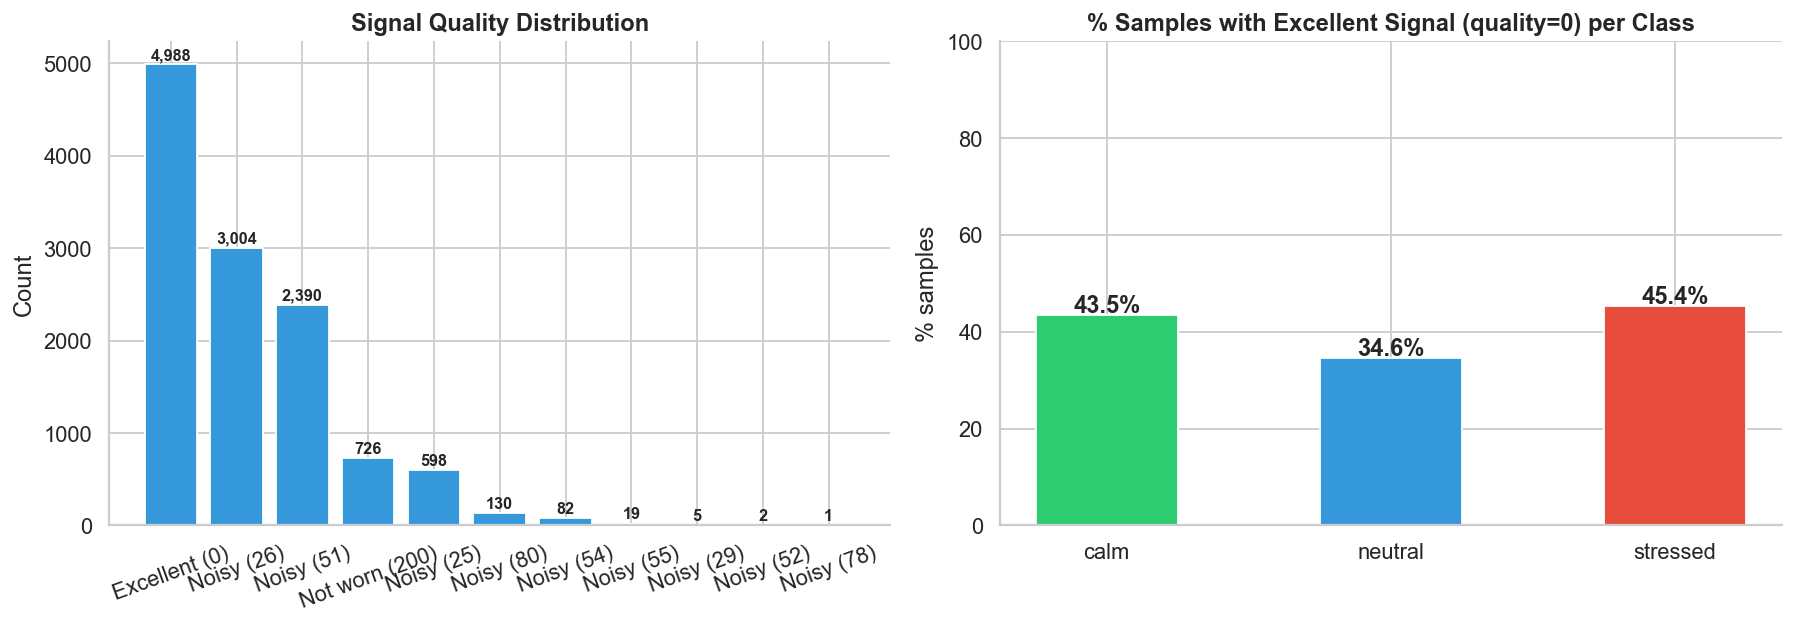

In [19]:
# signal_quality: 0=excellent, 200=not worn, other=noisy
def sig_category(v):
    if v == 0:   return "Excellent (0)"
    if v == 200: return "Not worn (200)"
    return f"Noisy ({v})"

df["sig_cat"] = df["signal_quality"].apply(sig_category)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution overall
ax = axes[0]
counts = df["sig_cat"].value_counts()
bars = ax.bar(counts.index, counts.values, color="#3498db", edgecolor="white")
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{cnt:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Signal Quality Distribution", fontweight="bold")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)

# Signal quality vs class
ax = axes[1]
q_class = df.groupby("label_3class", observed=True)["signal_quality"].value_counts(normalize=True).unstack(fill_value=0)
# Simplify: show % with excellent signal
pct_good = df.groupby("label_3class", observed=True).apply(
    lambda g: (g["signal_quality"] == 0).mean() * 100
).reindex(CLASS_ORDER)
ax.bar(CLASS_ORDER, pct_good.values, color=PALETTE, edgecolor="white", width=0.5)
for i, v in enumerate(pct_good.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_title("% Samples with Excellent Signal (quality=0) per Class", fontweight="bold")
ax.set_ylabel("% samples")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 13. PCA — Low-Dimensional View

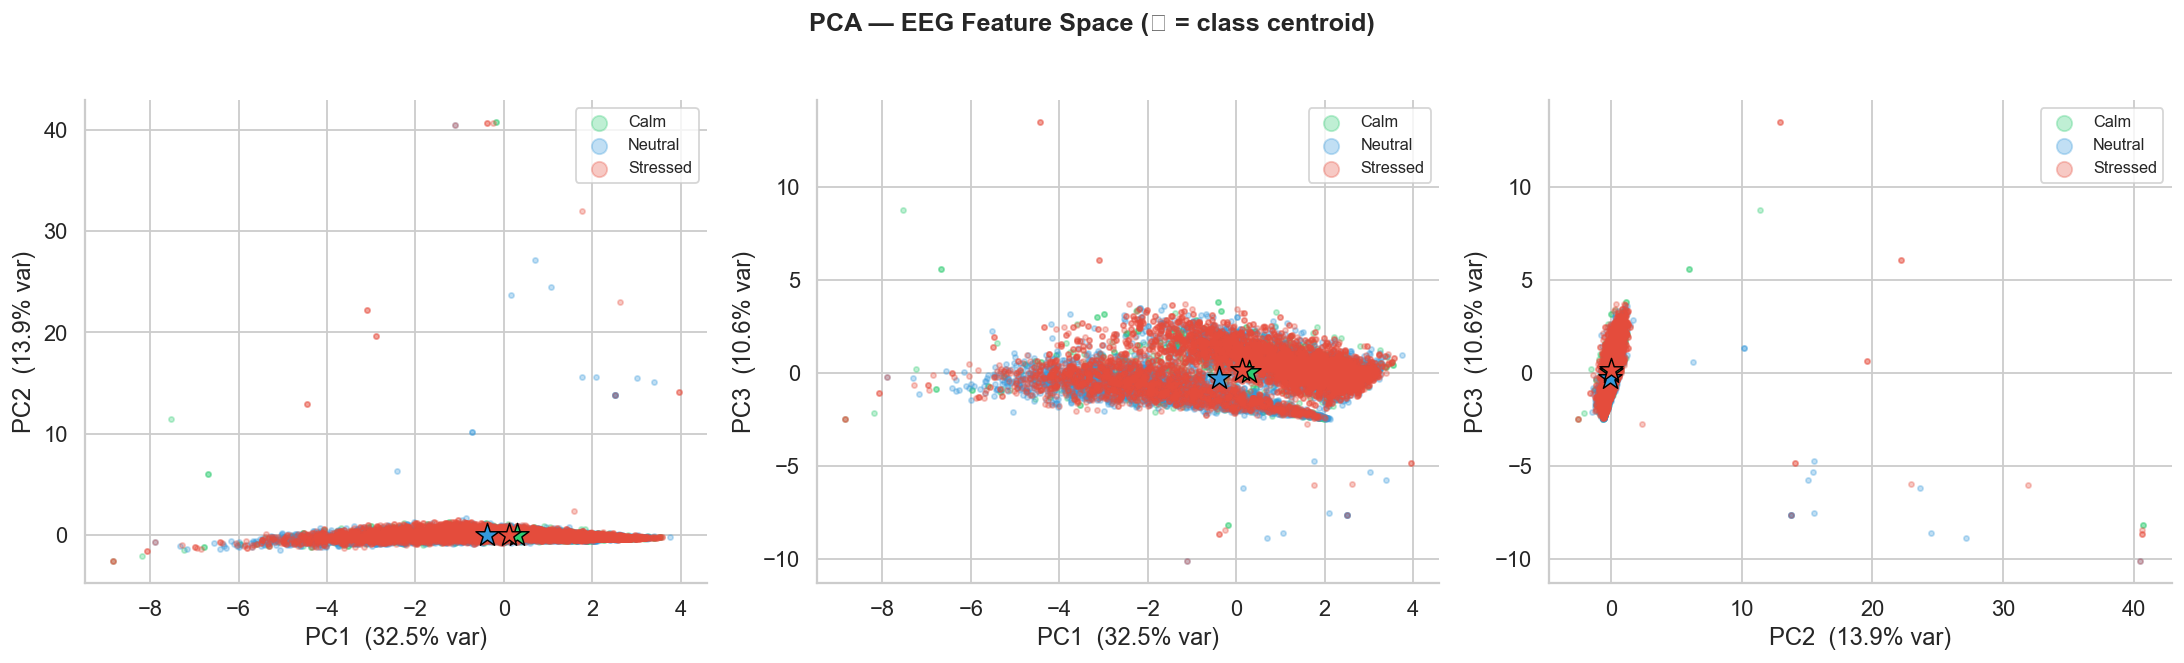

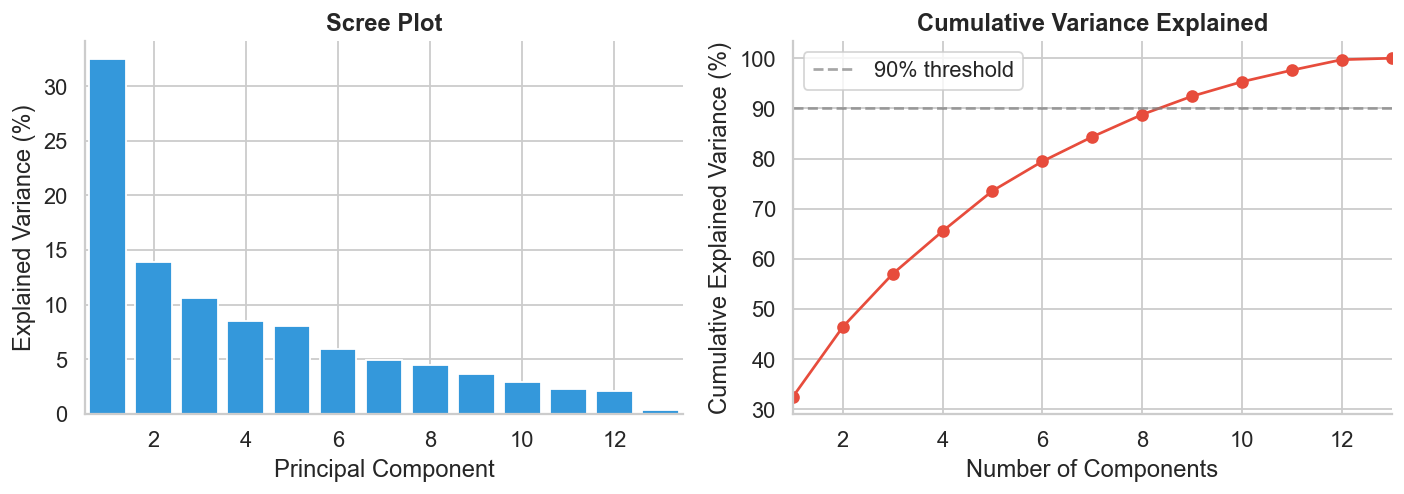

PC1 and PC2 loadings (top features):


theta-beta-ratio    0.657287
slow-fast-ratio     0.646161
delta               0.552691
theta               0.467361
low-gamma           0.453645
high-beta           0.444120
low-beta            0.417105
meditation          0.344008
dtype: float64

In [20]:
feature_cols = BAND_COLS + ["attention", "meditation"] + RATIO_COLS
X = df[feature_cols].copy()
X = X.fillna(X.median())
y = df["label_3class"].astype(str)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(4)])
pca_df["label"] = y.values

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

pairs = [("PC1", "PC2"), ("PC1", "PC3"), ("PC2", "PC3")]
for ax, (pcx, pcy) in zip(axes, pairs):
    for cls in CLASS_ORDER:
        sub = pca_df[pca_df["label"] == cls]
        ax.scatter(sub[pcx], sub[pcy], c=CLASS_COLORS[cls],
                   label=cls.capitalize(), alpha=0.3, s=8, rasterized=True)
    # Centroids
    for cls in CLASS_ORDER:
        cx = pca_df.loc[pca_df["label"] == cls, pcx].mean()
        cy = pca_df.loc[pca_df["label"] == cls, pcy].mean()
        ax.scatter(cx, cy, c=CLASS_COLORS[cls], s=180, marker="*",
                   edgecolors="black", linewidths=0.8, zorder=5)
    px_idx = int(pcx[2]) - 1
    py_idx = int(pcy[2]) - 1
    ax.set_xlabel(f"{pcx}  ({var_exp[px_idx]*100:.1f}% var)")
    ax.set_ylabel(f"{pcy}  ({var_exp[py_idx]*100:.1f}% var)")
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle("PCA — EEG Feature Space (★ = class centroid)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pca_full = PCA(random_state=42).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100, color="#3498db")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot", fontweight="bold")
axes[0].set_xlim(0.5, min(15, len(pca_full.explained_variance_ratio_)) + 0.5)

axes[1].plot(range(1, len(cum_var) + 1), cum_var * 100, marker="o", color="#e74c3c")
axes[1].axhline(90, linestyle="--", color="gray", alpha=0.7, label="90% threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Variance Explained", fontweight="bold")
axes[1].legend()
axes[1].set_xlim(1, min(15, len(cum_var)))

plt.tight_layout()
plt.show()

# PCA loadings
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=[c.replace("_pct", "").replace("_", "-") for c in feature_cols],
    columns=["PC1", "PC2"]
)
print("PC1 and PC2 loadings (top features):")
loadings.abs().sum(axis=1).sort_values(ascending=False).head(8)

## 14. t-SNE — Cluster Separation

Running t-SNE on 3000 samples ...


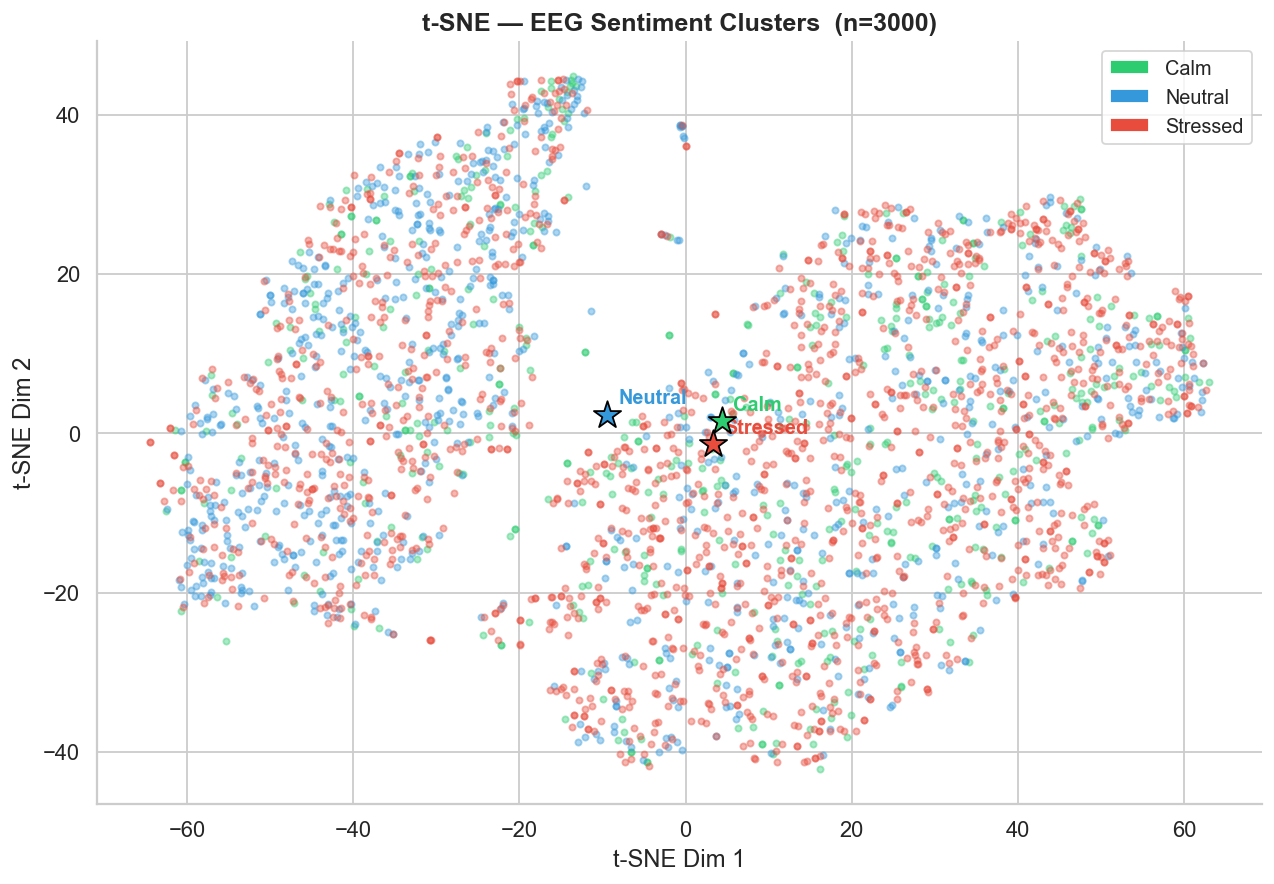

In [21]:
# Subsample for speed
N_TSNE = 3000
idx = df.sample(N_TSNE, random_state=42).index
X_sub = X_scaled[idx]
y_sub = y.iloc[idx].values

print(f"Running t-SNE on {N_TSNE} samples ...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000, learning_rate="auto")
X_tsne = tsne.fit_transform(X_sub)

tsne_df = pd.DataFrame(X_tsne, columns=["tSNE-1", "tSNE-2"])
tsne_df["label"] = y_sub

fig, ax = plt.subplots(figsize=(10, 7))
for cls in CLASS_ORDER:
    sub = tsne_df[tsne_df["label"] == cls]
    ax.scatter(sub["tSNE-1"], sub["tSNE-2"],
               c=CLASS_COLORS[cls], label=cls.capitalize(),
               alpha=0.4, s=12, rasterized=True)

# Convex hull around each class centroid region
for cls in CLASS_ORDER:
    sub = tsne_df[tsne_df["label"] == cls]
    cx, cy = sub["tSNE-1"].mean(), sub["tSNE-2"].mean()
    ax.scatter(cx, cy, c=CLASS_COLORS[cls], s=250, marker="*",
               edgecolors="black", linewidths=1, zorder=6)
    ax.annotate(cls.capitalize(), (cx, cy),
                textcoords="offset points", xytext=(6, 6),
                fontsize=11, fontweight="bold", color=CLASS_COLORS[cls])

ax.set_title(f"t-SNE — EEG Sentiment Clusters  (n={N_TSNE})",
             fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE Dim 1")
ax.set_ylabel("t-SNE Dim 2")
legend_elems = [Patch(facecolor=CLASS_COLORS[c], label=c.capitalize()) for c in CLASS_ORDER]
ax.legend(handles=legend_elems, fontsize=11)
plt.tight_layout()
plt.show()

## 15. Per-Participant Variability

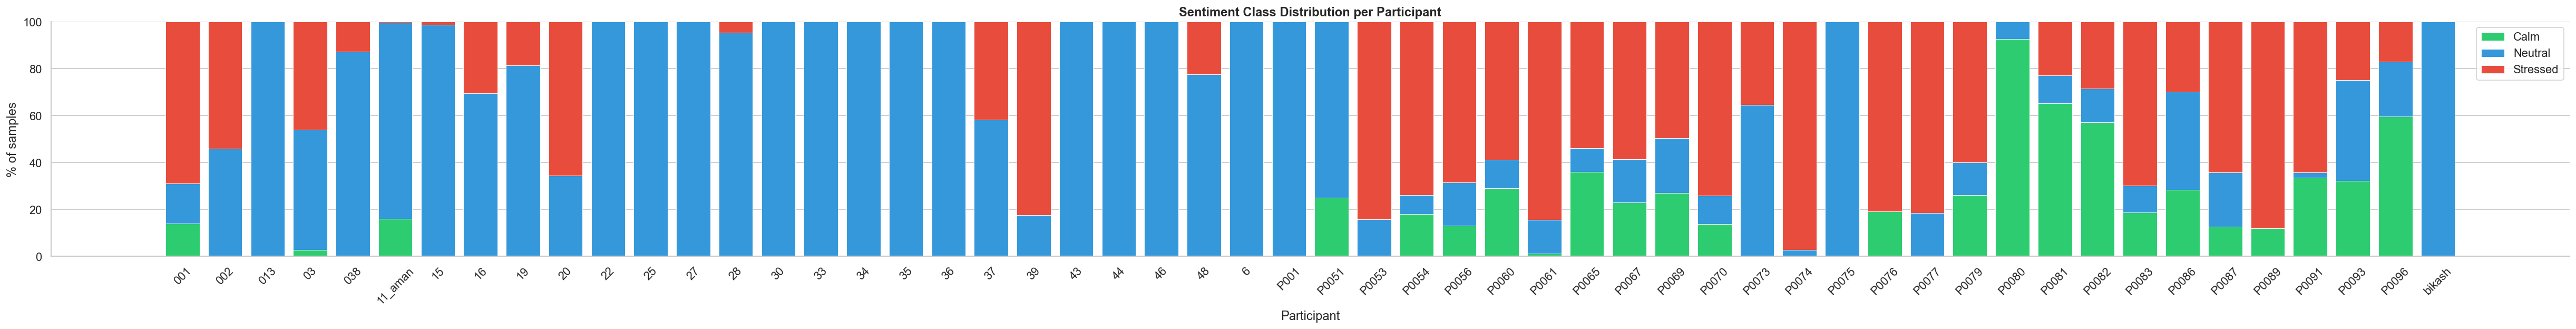

In [22]:
# Class distribution per participant
part_class = df.groupby(["participant_id", "label_3class"], observed=True).size().unstack(fill_value=0)
part_class = part_class.reindex(columns=CLASS_ORDER, fill_value=0)
part_class_pct = part_class.div(part_class.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(max(10, len(part_class) * 0.7), 5))
bottom = np.zeros(len(part_class_pct))
for cls in CLASS_ORDER:
    ax.bar(part_class_pct.index, part_class_pct[cls],
           bottom=bottom, label=cls.capitalize(),
           color=CLASS_COLORS[cls], edgecolor="white", linewidth=0.5)
    bottom += part_class_pct[cls].values

ax.set_xlabel("Participant")
ax.set_ylabel("% of samples")
ax.set_title("Sentiment Class Distribution per Participant", fontweight="bold")
ax.legend(loc="upper right")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

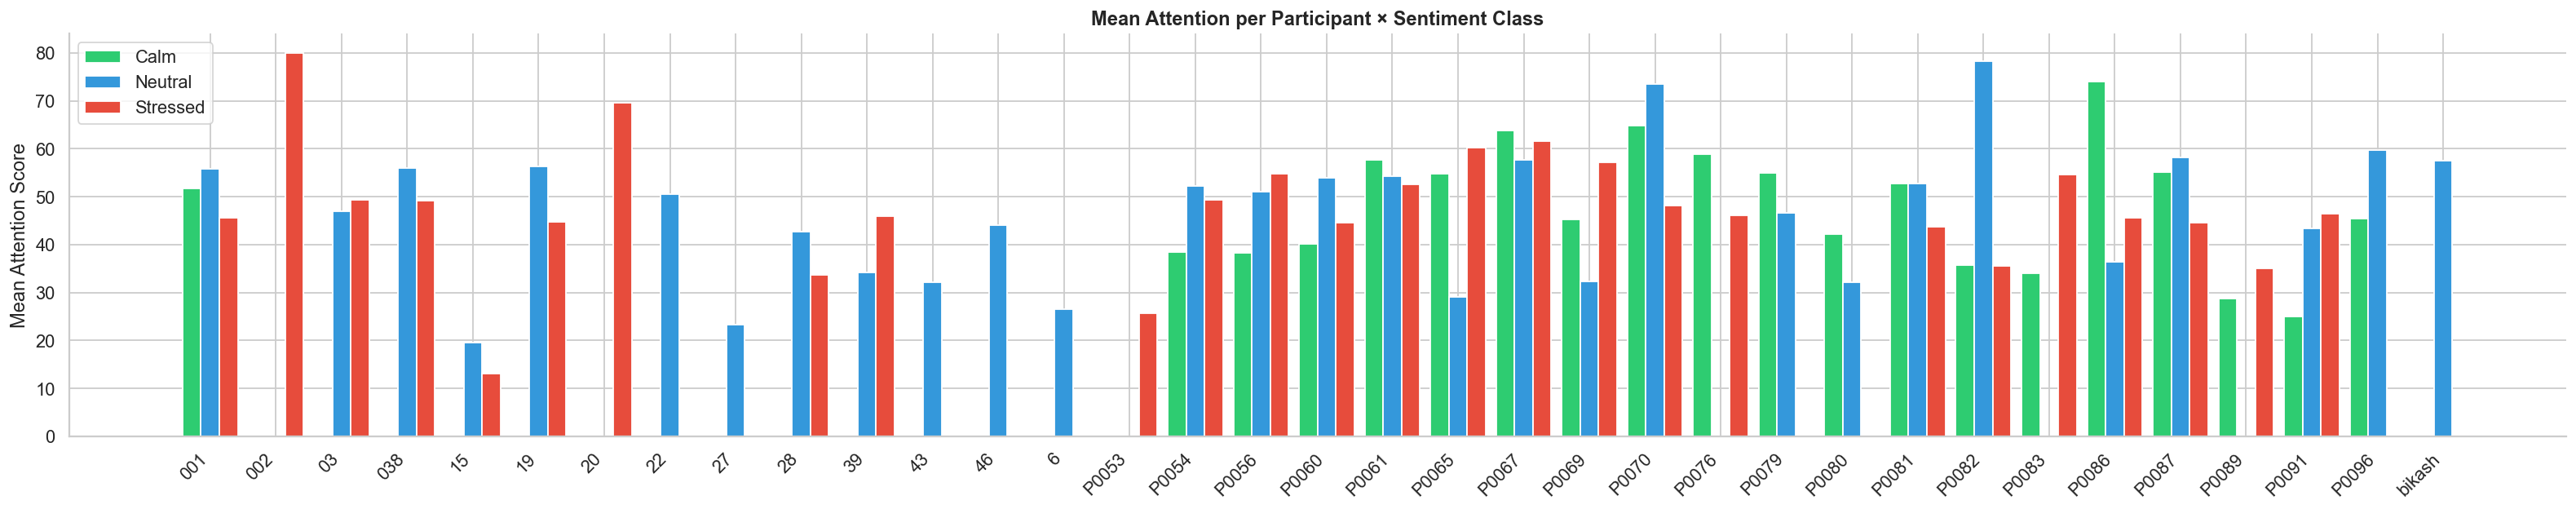

In [23]:
# Attention mean per participant, split by class
part_att = df[df["attention"] > 0].groupby(
    ["participant_id", "label_3class"], observed=True
)["attention"].mean().unstack(fill_value=np.nan).reindex(columns=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(max(10, len(part_att) * 0.7), 5))
x = np.arange(len(part_att))
w = 0.28
for i, cls in enumerate(CLASS_ORDER):
    ax.bar(x + i * w, part_att[cls], w, label=cls.capitalize(),
           color=CLASS_COLORS[cls], edgecolor="white")
ax.set_xticks(x + w)
ax.set_xticklabels(part_att.index, rotation=45, ha="right")
ax.set_ylabel("Mean Attention Score")
ax.set_title("Mean Attention per Participant × Sentiment Class", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Key finding summary
print("="*60)
print("KEY FINDINGS SUMMARY")
print("="*60)

for cls in CLASS_ORDER:
    sub = df[df["label_3class"] == cls]
    print(f"\n  {cls.upper()} ({len(sub):,} samples)")
    print(f"    Dominant band   : {sub[BAND_COLS].mean().idxmax().replace('_pct','').replace('_','-')}")
    print(f"    Attention (mean): {sub.loc[sub['attention']>0,'attention'].mean():.1f}")
    print(f"    Meditation(mean): {sub.loc[sub['meditation']>0,'meditation'].mean():.1f}")
    print(f"    Theta/Beta ratio: {sub['theta_beta_ratio'].median():.2f} (median)")

print("\nDataset imbalance — consider oversampling (SMOTE) or class-weighted models.")

KEY FINDINGS SUMMARY

  CALM (2,097 samples)
    Dominant band   : delta
    Attention (mean): 47.5
    Meditation(mean): 53.5
    Theta/Beta ratio: 2.91 (median)

  NEUTRAL (3,662 samples)
    Dominant band   : delta
    Attention (mean): 48.9
    Meditation(mean): 52.3
    Theta/Beta ratio: 2.32 (median)

  STRESSED (6,186 samples)
    Dominant band   : delta
    Attention (mean): 50.4
    Meditation(mean): 51.6
    Theta/Beta ratio: 2.89 (median)

Dataset imbalance — consider oversampling (SMOTE) or class-weighted models.
